In [1]:
import pandas as pd
import numpy as np
import os
import glob
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [3]:
import zipfile
import os
import glob

zip_path = r"C:\Users\Tripti Malhotra\Downloads\collections_30k_dataset (1).zip"
extract_folder = "collections_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)

print("Files successfully extracted!")


Files successfully extracted!


In [4]:
csv_files = glob.glob(
    os.path.join(extract_folder, "**", "*.csv"),
    recursive=True
)

print(f"Total CSV files found: {len(csv_files)}")

for file in sorted(csv_files):
    print(os.path.relpath(file, extract_folder))

Total CSV files found: 18
account_status_history.csv
accounts.csv
agent_sessions.csv
agents.csv
borrowers.csv
call_attempts.csv
call_dispositions.csv
calls.csv
campaigns.csv
complaints.csv
daily_targeting.csv
data_dictionary.csv
field_visits.csv
payments.csv
promises_to_pay.csv
sms_events.csv
vendor_telephony.csv
whatsapp_events.csv


In [5]:
# Load all CSV files into a dictionary

data = {}

for file in csv_files:
    table_name = os.path.splitext(os.path.basename(file))[0]
    data[table_name] = pd.read_csv(file)

print(f"Total datasets loaded: {len(data)}")

for name, df in data.items():
    print(f"{name}: {df.shape[0]:,} rows × {df.shape[1]} columns")

Total datasets loaded: 18
accounts: 30,000 rows × 11 columns
account_status_history: 60,000 rows × 8 columns
agents: 30,000 rows × 8 columns
agent_sessions: 15,000 rows × 7 columns
borrowers: 30,600 rows × 8 columns
calls: 91,350 rows × 11 columns
call_attempts: 120,000 rows × 9 columns
call_dispositions: 35,000 rows × 8 columns
campaigns: 120 rows × 7 columns
complaints: 8,000 rows × 9 columns
daily_targeting: 45,000 rows × 7 columns
data_dictionary: 143 rows × 3 columns
field_visits: 25,000 rows × 10 columns
payments: 25,500 rows × 9 columns
promises_to_pay: 18,000 rows × 9 columns
sms_events: 45,000 rows × 8 columns
vendor_telephony: 15 rows × 6 columns
whatsapp_events: 60,600 rows × 8 columns


In [6]:
inventory = []

for name, df in data.items():
    inventory.append({
        "dataset": name,
        "rows": len(df),
        "columns": len(df.columns),
        "duplicate_rows": df.duplicated().sum(),
        "total_missing_values": df.isna().sum().sum(),
        "missing_cells_%": round(
            df.isna().sum().sum() / df.size * 100, 2
        ),
        "memory_MB": round(
            df.memory_usage(deep=True).sum() / (1024**2), 2
        )
    })

inventory_df = (
    pd.DataFrame(inventory)
    .sort_values("rows", ascending=False)
    .reset_index(drop=True)
)

inventory_df

,dataset,rows,columns,duplicate_rows,total_missing_values,missing_cells_%,memory_MB
0,call_attempts,120000,9,0,2400,0.22,56.13
1,calls,91350,11,1271,1827,0.18,52.35
2,whatsapp_events,60600,8,600,0,0.00,28.41
3,account_status_history,60000,8,0,0,0.00,27.73
4,sms_events,45000,8,0,0,0.00,20.86
5,daily_targeting,45000,7,0,0,0.00,15.21
6,call_dispositions,35000,8,0,0,0.00,16.08
7,borrowers,30600,8,600,1509,0.62,12.98
8,accounts,30000,11,0,455,0.14,13.79
9,agents,30000,8,0,0,0.00,13.73


In [7]:
column_profile = []

for name, df in data.items():
    for col in df.columns:
        column_profile.append({
            "dataset": name,
            "column": col,
            "dtype": str(df[col].dtype),
            "unique_values": df[col].nunique(dropna=True),
            "missing_count": df[col].isna().sum(),
            "missing_%": round(df[col].isna().mean() * 100, 2)
        })

column_profile_df = (
    pd.DataFrame(column_profile)
    .sort_values(
        ["dataset", "missing_%"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

column_profile_df

,dataset,column,dtype,unique_values,missing_count,missing_%
0,account_status_history,history_id,str,60000,0,0.00
1,account_status_history,account_id,str,25999,0,0.00
2,account_status_history,borrower_id,str,11916,0,0.00
3,account_status_history,event_at,str,59898,0,0.00
4,account_status_history,status,str,7,0,0.00
...,...,...,...,...,...,...
141,whatsapp_events,event_at,str,59892,0,0.00
142,whatsapp_events,message_id,str,34831,0,0.00
143,whatsapp_events,event_type,str,6,0,0.00
144,whatsapp_events,template_code,str,5,0,0.00


In [8]:
data["data_dictionary"].head(20)

,dataset,column,dtype
0,borrowers,borrower_id,object
1,borrowers,name,object
2,borrowers,phone,object
3,borrowers,email,object
4,borrowers,city,object
5,borrowers,created_at,datetime64[ns]
6,borrowers,updated_at,datetime64[ns]
7,borrowers,state,object
8,accounts,account_id,object
9,accounts,borrower_id,object


In [9]:
data["data_dictionary"].to_string(index=False)

'               dataset              column          dtype\n             borrowers         borrower_id         object\n             borrowers                name         object\n             borrowers               phone         object\n             borrowers               email         object\n             borrowers                city         object\n             borrowers          created_at datetime64[ns]\n             borrowers          updated_at datetime64[ns]\n             borrowers               state         object\n              accounts          account_id         object\n              accounts         borrower_id         object\n              accounts           loan_type         object\n              accounts    principal_amount        float64\n              accounts  outstanding_amount        float64\n              accounts                 dpd          int64\n              accounts        risk_segment         object\n              accounts              status         obje

In [10]:
candidate_keys = {
    "borrowers": ["borrower_id"],
    "accounts": ["account_id"],
    "agents": ["agent_id"],
    "agent_sessions": ["session_id"],
    "campaigns": ["campaign_id"],
    "daily_targeting": ["target_id"],
    "calls": ["call_id"],
    "call_attempts": ["attempt_id"],
    "call_dispositions": ["disposition_id"],
    "whatsapp_events": ["whatsapp_event_id"],
    "sms_events": ["sms_event_id"],
    "field_visits": ["visit_id"],
    "promises_to_pay": ["ptp_id"],
    "payments": ["payment_id"],
    "vendor_telephony": ["vendor_id"],
    "complaints": ["complaint_id"],
    "account_status_history": ["history_id"]
}

key_profile = []

for dataset, keys in candidate_keys.items():
    df = data[dataset]

    for key in keys:
        key_profile.append({
            "dataset": dataset,
            "key": key,
            "rows": len(df),
            "unique_keys": df[key].nunique(dropna=True),
            "null_keys": df[key].isna().sum(),
            "duplicate_key_rows": df[key].duplicated(keep=False).sum(),
            "is_unique": df[key].nunique(dropna=True) == len(df)
        })

key_profile_df = pd.DataFrame(key_profile)

key_profile_df

,dataset,key,rows,unique_keys,null_keys,duplicate_key_rows,is_unique
0,borrowers,borrower_id,30600,11015,0,28151,False
1,accounts,account_id,30000,30000,0,0,True
2,agents,agent_id,30000,1000,0,30000,False
3,agent_sessions,session_id,15000,15000,0,0,True
4,campaigns,campaign_id,120,120,0,0,True
5,daily_targeting,target_id,45000,45000,0,0,True
6,calls,call_id,91350,90000,0,2700,False
7,call_attempts,attempt_id,120000,120000,0,0,True
8,call_dispositions,disposition_id,35000,35000,0,0,True
9,whatsapp_events,whatsapp_event_id,60600,60000,0,1200,False


In [11]:
borrowers = data["borrowers"]

borrower_duplicates = (
    borrowers[
        borrowers["borrower_id"].duplicated(keep=False)
    ]
    .sort_values("borrower_id")
)

print(f"Rows with duplicated borrower_id: {len(borrower_duplicates):,}")
print(f"Unique duplicated borrower_ids: {borrower_duplicates['borrower_id'].nunique():,}")

borrower_duplicates.head(30)


Rows with duplicated borrower_id: 28,151
Unique duplicated borrower_ids: 8,566


,borrower_id,name,phone,email,city,created_at,updated_at,state
5082,BRW0000001,Aarav Sharma,"9,962,893,468.00",user8164@example.com,Kolkata,2025-11-04 23:36:22,2026-06-22 12:05:30,West Bengal
27686,BRW0000001,Aarav Sharma,"9,237,817,865.00",user10670@example.com,Hyderabad,2025-12-03 00:18:45,2026-06-25 02:44:50,Telangana
20435,BRW0000001,Rohan Patel,"9,712,906,834.00",user4799@example.com,Hyderabad,2026-07-17 04:33:13,2025-11-22 01:34:14,Telangana
20050,BRW0000004,Vikram Shah,"9,072,500,921.00",user13710@example.com,Gurugram,2025-11-16 08:32:03,2025-10-31 11:10:43,Haryana
23818,BRW0000004,Ananya Rao,"9,076,786,709.00",user15119@example.com,Delhi,2025-07-20 23:45:10,2025-12-20 18:43:35,Delhi
10963,BRW0000004,Neha Singh,"9,714,460,582.00",user18767@example.com,Bengaluru,2025-07-03 17:14:49,2025-01-15 08:16:46,Karnataka
29546,BRW0000004,Pooja Nair,"9,936,985,398.00",user11254@example.com,Mumbai,2026-02-10 12:40:50,2025-12-16 20:36:28,Maharashtra
30325,BRW0000005,Neha Singh,"9,269,812,849.00",user4520@example.com,Mumbai,2026-02-07 14:08:27,2025-12-04 08:52:09,Maharashtra
18692,BRW0000005,Neha Singh,"9,269,812,849.00",user4520@example.com,Mumbai,2026-02-07 14:08:27,2025-12-04 08:52:09,Maharashtra
8282,BRW0000005,Sneha Das,"9,359,022,559.00",user5979@example.com,Pune,2026-03-18 14:01:59,2025-07-07 09:59:12,Maharashtra


In [12]:
borrower_frequency = (
    borrowers
    .groupby("borrower_id")
    .size()
    .reset_index(name="record_count")
    .sort_values("record_count", ascending=False)
)

borrower_frequency.head(20)

,borrower_id,record_count
5812,BRW0006302,11
8150,BRW0008879,11
4966,BRW0005385,10
2327,BRW0002520,10
1153,BRW0001237,10
3796,BRW0004112,9
10144,BRW0011052,9
9241,BRW0010060,9
3731,BRW0004044,9
6461,BRW0007009,9


In [13]:
borrower_dup_analysis = (
    borrowers
    .groupby("borrower_id")
    .agg(
        total_records=("borrower_id", "size"),
        unique_names=("name", "nunique"),
        unique_phones=("phone", "nunique"),
        unique_emails=("email", "nunique"),
        unique_cities=("city", "nunique"),
        unique_states=("state", "nunique")
    )
    .reset_index()
)

borrower_dup_analysis["has_conflict"] = (
    (borrower_dup_analysis["unique_names"] > 1) |
    (borrower_dup_analysis["unique_phones"] > 1) |
    (borrower_dup_analysis["unique_emails"] > 1) |
    (borrower_dup_analysis["unique_cities"] > 1) |
    (borrower_dup_analysis["unique_states"] > 1)
)

print("Borrower IDs with conflicting attributes:",
      borrower_dup_analysis["has_conflict"].sum())

print("Borrower IDs with no attribute conflict:",
      (~borrower_dup_analysis["has_conflict"]).sum())

borrower_dup_analysis.sort_values(
    "total_records", ascending=False
).head(20)

Borrower IDs with conflicting attributes: 8518
Borrower IDs with no attribute conflict: 2497


,borrower_id,total_records,unique_names,unique_phones,unique_emails,unique_cities,unique_states,has_conflict
5812,BRW0006302,11,7,10,10,7,6,True
8150,BRW0008879,11,7,11,10,8,7,True
4966,BRW0005385,10,7,10,10,5,4,True
2327,BRW0002520,10,7,10,10,5,5,True
1153,BRW0001237,10,9,10,10,7,6,True
3796,BRW0004112,9,6,8,8,5,5,True
10144,BRW0011052,9,7,9,9,6,6,True
9241,BRW0010060,9,5,9,9,7,6,True
3731,BRW0004044,9,7,8,8,4,4,True
6461,BRW0007009,9,5,8,9,7,7,True


In [14]:
borrower_time_check = borrowers.copy()

borrower_time_check["created_at"] = pd.to_datetime(
    borrower_time_check["created_at"],
    errors="coerce"
)

borrower_time_check["updated_at"] = pd.to_datetime(
    borrower_time_check["updated_at"],
    errors="coerce"
)

borrower_time_check["updated_before_created"] = (
    borrower_time_check["updated_at"]
    < borrower_time_check["created_at"]
)

print(
    "Records where updated_at < created_at:",
    borrower_time_check["updated_before_created"].sum()
)

print(
    "Percentage:",
    round(
        borrower_time_check["updated_before_created"].mean() * 100,
        2
    ),
    "%"
)

Records where updated_at < created_at: 15354
Percentage: 50.18 %


In [15]:
print("created_at range:")
print(borrower_time_check["created_at"].min())
print(borrower_time_check["created_at"].max())

print("\nupdated_at range:")
print(borrower_time_check["updated_at"].min())
print(borrower_time_check["updated_at"].max())

created_at range:
2025-01-01 00:14:38
2026-08-03 23:37:55

updated_at range:
2025-01-01 00:19:40
2026-08-03 23:48:36


In [16]:
accounts = data["accounts"]

account_borrower_check = accounts["borrower_id"].isin(
    set(borrowers["borrower_id"])
)

print("Total accounts:", len(accounts))
print("Accounts with borrower_id:", accounts["borrower_id"].notna().sum())
print("Accounts with matching borrower_id:", account_borrower_check.sum())
print("Accounts with unmatched borrower_id:", 
      (~account_borrower_check & accounts["borrower_id"].notna()).sum())

Total accounts: 30000
Accounts with borrower_id: 29545
Accounts with matching borrower_id: 27087
Accounts with unmatched borrower_id: 2458


In [17]:
payments = data["payments"]

payment_id_check = (
    payments
    .groupby("payment_id")
    .agg(
        record_count=("payment_id", "size"),
        unique_accounts=("account_id", "nunique"),
        unique_borrowers=("borrower_id", "nunique"),
        total_amount=("amount", "sum"),
        unique_amounts=("amount", "nunique"),
        unique_references=("payment_reference", "nunique"),
        unique_statuses=("payment_status", "nunique")
    )
    .reset_index()
    .sort_values("record_count", ascending=False)
)

payment_id_check.head(20)

,payment_id,record_count,unique_accounts,unique_borrowers,total_amount,unique_amounts,unique_references,unique_statuses
11758,PAYMENT0011759,2,1,1,"65,853.92",1,1,1
793,PAYMENT0000794,2,1,1,"45,991.12",1,1,1
7581,PAYMENT0007582,2,1,1,"239,428.40",1,1,1
9865,PAYMENT0009866,2,1,1,"268,777.16",1,1,1
2241,PAYMENT0002242,2,1,1,"66,209.94",1,1,1
11613,PAYMENT0011614,2,1,1,"70,372.34",1,1,1
12247,PAYMENT0012248,2,1,1,"49,242.24",1,1,1
3451,PAYMENT0003452,2,1,1,"157,521.14",1,1,1
7965,PAYMENT0007966,2,1,1,723.04,1,1,1
2246,PAYMENT0002247,2,1,1,"182,990.48",1,1,1


In [18]:
duplicate_payment_ids = payment_id_check[
    payment_id_check["record_count"] > 1
]

print("Duplicate payment IDs:",
      len(duplicate_payment_ids))

print("Rows belonging to duplicate payment IDs:",
      duplicate_payment_ids["record_count"].sum())

print("Excess duplicate rows:",
      duplicate_payment_ids["record_count"].sum()
      - len(duplicate_payment_ids))

print("Amount recorded across duplicate rows: ₹{:,.2f}".format(
    duplicate_payment_ids["total_amount"].sum()
))


Duplicate payment IDs: 500
Rows belonging to duplicate payment IDs: 1000
Excess duplicate rows: 500
Amount recorded across duplicate rows: ₹76,732,688.52


In [19]:
payment_duplicate_rows = payments[
    payments["payment_id"].duplicated(keep=False)
].copy()

payment_duplicate_comparison = (
    payment_duplicate_rows
    .groupby("payment_id")
    .agg(
        rows=("payment_id", "size"),
        unique_accounts=("account_id", "nunique"),
        unique_borrowers=("borrower_id", "nunique"),
        unique_amounts=("amount", "nunique"),
        unique_references=("payment_reference", "nunique"),
        unique_statuses=("payment_status", "nunique"),
        unique_methods=("payment_method", "nunique"),
        unique_providers=("provider_id", "nunique"),
        unique_timestamps=("event_at", "nunique")
    )
    .reset_index()
)

payment_duplicate_comparison.head(20)

,payment_id,rows,unique_accounts,unique_borrowers,unique_amounts,unique_references,unique_statuses,unique_methods,unique_providers,unique_timestamps
0,PAYMENT0000056,2,1,1,1,1,1,1,1,1
1,PAYMENT0000076,2,1,1,1,1,1,1,1,1
2,PAYMENT0000108,2,1,1,1,1,1,1,1,1
3,PAYMENT0000149,2,1,1,1,1,1,1,1,1
4,PAYMENT0000199,2,1,1,1,1,1,1,1,1
5,PAYMENT0000255,2,1,1,1,1,1,1,1,1
6,PAYMENT0000263,2,1,1,1,1,1,1,1,1
7,PAYMENT0000311,2,1,1,1,1,1,1,1,1
8,PAYMENT0000552,2,1,1,1,1,1,1,1,1
9,PAYMENT0000553,2,1,1,1,1,1,1,1,1


In [20]:
duplicate_check_cols = [
    "account_id",
    "borrower_id",
    "event_at",
    "payment_reference",
    "amount",
    "payment_status",
    "payment_method",
    "provider_id"
]

duplicate_groups = (
    payments[
        payments["payment_id"].duplicated(keep=False)
    ]
    .groupby("payment_id")[duplicate_check_cols]
    .nunique(dropna=False)
)

non_identical_duplicates = duplicate_groups[
    (duplicate_groups > 1).any(axis=1)
]

print("Total duplicate payment IDs:", len(duplicate_groups))
print("Duplicate IDs with conflicting fields:", len(non_identical_duplicates))
print("Exact duplicate payment IDs:", 
      len(duplicate_groups) - len(non_identical_duplicates))

Total duplicate payment IDs: 500
Duplicate IDs with conflicting fields: 14
Exact duplicate payment IDs: 486


In [21]:
conflicting_payment_ids = non_identical_duplicates.index

conflicting_payments = (
    payments[
        payments["payment_id"].isin(conflicting_payment_ids)
    ]
    .sort_values("payment_id")
)

conflicting_payments

,payment_id,account_id,borrower_id,event_at,payment_reference,amount,payment_status,payment_method,provider_id
1389,PAYMENT0001390,ACC0001624,BRW0004200,2026-05-14 07:52:59,TXN0000046535,"85,205.16",SUCCESS,CASH,VND0000015
25043,PAYMENT0001390,ACC0001624,BRW0004200,2026-05-14 07:52:59,NaN,"85,205.16",SUCCESS,CASH,VND0000015
2097,PAYMENT0002098,ACC0023839,BRW0008653,2026-07-01 09:19:16,TXN0000001302,"5,570.92",SUCCESS,NETBANKING,VND0000001
25055,PAYMENT0002098,ACC0023839,BRW0008653,2026-07-01 09:19:16,NaN,"5,570.92",SUCCESS,NETBANKING,VND0000001
2302,PAYMENT0002303,ACC0021362,BRW0001779,2026-06-15 03:09:47,TXN0000067311,"59,429.86",SUCCESS,CARD,VND0000011
25057,PAYMENT0002303,ACC0021362,BRW0001779,2026-06-15 03:09:47,NaN,"59,429.86",SUCCESS,CARD,VND0000011
25437,PAYMENT0005191,ACC0001901,BRW0001234,2026-06-28 13:50:03,TXN0000041890,"107,235.47",SUCCESS,NACH,VND0000002
5190,PAYMENT0005191,ACC0001901,BRW0001234,2026-06-28 13:50:03,NaN,"107,235.47",SUCCESS,NACH,VND0000002
25385,PAYMENT0007582,ACC0017962,BRW0008041,2026-03-26 12:49:42,TXN0000013106,"119,714.20",SUCCESS,NETBANKING,VND0000014
7581,PAYMENT0007582,ACC0017962,BRW0008041,2026-03-26 12:49:42,NaN,"119,714.20",SUCCESS,NETBANKING,VND0000014


In [22]:
payment_status_summary = (
    payments
    .groupby("payment_status")
    .agg(
        transactions=("payment_id", "count"),
        unique_payment_ids=("payment_id", "nunique"),
        total_amount=("amount", "sum")
    )
    .reset_index()
)

payment_status_summary

,payment_status,transactions,unique_payment_ids,total_amount
0,FAILED,3744,3677,"283,506,324.89"
1,PENDING,2592,2535,"194,867,950.33"
2,REVERSED,1284,1254,"97,398,415.60"
3,SUCCESS,17880,17534,"1,341,485,926.33"


In [23]:
success_payments = payments[
    payments["payment_status"].eq("SUCCESS")
]

success_duplicate_ids = (
    success_payments["payment_id"]
    [success_payments["payment_id"].duplicated(keep=False)]
    .nunique()
)

success_duplicate_rows = (
    success_payments["payment_id"]
    [success_payments["payment_id"].duplicated(keep=False)]
    .shape[0]
)

success_duplicate_amount = success_payments[
    success_payments["payment_id"].duplicated(keep=False)
]["amount"].sum()

print("SUCCESS duplicate payment IDs:", success_duplicate_ids)
print("SUCCESS duplicate rows:", success_duplicate_rows)
print("SUCCESS duplicate amount: ₹{:,.2f}".format(
    success_duplicate_amount
))

SUCCESS duplicate payment IDs: 346
SUCCESS duplicate rows: 692
SUCCESS duplicate amount: ₹51,803,923.38


## PAYMENTS TIMESTAMPS

In [24]:
payments["event_at"] = pd.to_datetime(
    payments["event_at"],
    errors="coerce"
)

print("Payment event range:")
print(payments["event_at"].min())
print(payments["event_at"].max())

print("\nMissing payment timestamps:")
print(payments["event_at"].isna().sum())

Payment event range:
2026-01-01 00:14:40
2026-08-08 23:50:23

Missing payment timestamps:
0


In [25]:
monthly_payments = (
    payments
    .assign(month=payments["event_at"].dt.to_period("M").astype(str))
    .groupby(["month", "payment_status"])
    .agg(
        transactions=("payment_id", "count"),
        unique_payments=("payment_id", "nunique"),
        amount=("amount", "sum")
    )
    .reset_index()
)

monthly_payments

,month,payment_status,transactions,unique_payments,amount
0,2026-01,FAILED,528,515,"38,992,112.84"
1,2026-01,PENDING,384,375,"29,195,406.81"
2,2026-01,REVERSED,176,174,"11,797,262.23"
3,2026-01,SUCCESS,2515,2464,"191,133,284.42"
4,2026-02,FAILED,459,451,"35,548,386.52"
5,2026-02,PENDING,322,312,"23,781,450.26"
6,2026-02,REVERSED,142,140,"11,756,494.52"
7,2026-02,SUCCESS,2315,2268,"174,097,287.96"
8,2026-03,FAILED,538,533,"41,368,485.76"
9,2026-03,PENDING,344,334,"25,690,063.88"


In [26]:
date_columns = [
    "created_at",
    "updated_at",
    "opened_at",
    "joined_at",
    "login_at",
    "logout_at",
    "start_at",
    "end_at",
    "target_date",
    "event_at",
    "scheduled_at",
    "promised_date",
    "resolution_at",
    "recorded_at"
]

coverage = []

for name, df in data.items():
    available_dates = []
    
    for col in date_columns:
        if col in df.columns:
            temp = pd.to_datetime(df[col], errors="coerce")
            available_dates.extend(temp.dropna().tolist())
    
    if available_dates:
        coverage.append({
            "dataset": name,
            "min_date": min(available_dates),
            "max_date": max(available_dates),
            "date_records": len(available_dates)
        })

coverage_df = pd.DataFrame(coverage).sort_values("min_date")

coverage_df

,dataset,min_date,max_date,date_records
0,accounts,2024-01-01 00:02:27,2025-11-30 23:52:36,30000
2,agents,2024-01-01 00:10:05,2026-08-03 23:45:38,60000
4,borrowers,2025-01-01 00:14:38,2026-08-03 23:48:36,61200
5,calls,2025-12-29 06:52:37,2026-08-12 15:43:05,91350
1,account_status_history,2025-12-31 01:26:29,2026-08-09 22:02:27,120000
11,field_visits,2025-12-31 05:21:55,2026-08-08 23:50:03,49750
10,daily_targeting,2026-01-01 00:00:00,2026-08-08 00:00:00,45000
6,call_attempts,2026-01-01 00:01:18,2026-08-08 23:58:40,120000
15,whatsapp_events,2026-01-01 00:01:49,2026-08-08 23:56:16,60600
3,agent_sessions,2026-01-01 00:01:57,2026-08-09 07:50:12,30000


In [27]:
ptp = data["promises_to_pay"].copy()

ptp["event_at"] = pd.to_datetime(ptp["event_at"], errors="coerce")
ptp["promised_date"] = pd.to_datetime(ptp["promised_date"], errors="coerce")

print("PTP event_at range:")
print(ptp["event_at"].min(), "to", ptp["event_at"].max())

print("\nPTP promised_date range:")
print(ptp["promised_date"].min(), "to", ptp["promised_date"].max())

print("\nPTPs with promised_date after Aug 8, 2026:",
      (ptp["promised_date"] > pd.Timestamp("2026-08-08")).sum())

PTP event_at range:
2026-01-01 00:24:14 to 2026-08-08 23:59:33

PTP promised_date range:
2026-01-02 04:36:18 to 2026-09-06 21:23:52

PTPs with promised_date after Aug 8, 2026: 1339


In [28]:
ptp["status"].value_counts(dropna=False)

status
BROKEN       4553
CANCELLED    4543
KEPT         4489
OPEN         4415
Name: count, dtype: int64

In [29]:
ptp_kept = ptp[ptp["status"] == "KEPT"].copy()

payment_accounts = set(
    payments.loc[
        payments["payment_status"] == "SUCCESS",
        "account_id"
    ].dropna()
)

ptp_kept["has_success_payment"] = (
    ptp_kept["account_id"].isin(payment_accounts)
)

print("Source KEPT PTPs:", len(ptp_kept))
print(
    "KEPT PTPs with at least one SUCCESS payment:",
    ptp_kept["has_success_payment"].sum()
)
print(
    "KEPT PTPs without SUCCESS payment:",
    (~ptp_kept["has_success_payment"]).sum()
)

Source KEPT PTPs: 4489
KEPT PTPs with at least one SUCCESS payment: 2073
KEPT PTPs without SUCCESS payment: 2416


In [31]:
ptp_kept_payment_check = ptp_kept.merge(
    payments[
        payments["payment_status"] == "SUCCESS"
    ][["account_id", "event_at", "amount"]],
    on="account_id",
    how="left",
    suffixes=("_ptp", "_payment")
)

ptp_kept_payment_check["paid_on_or_before_promised_date"] = (
    ptp_kept_payment_check["event_at_payment"]
    <= ptp_kept_payment_check["promised_date"]
)

print(
    "PTP rows with SUCCESS payment:",
    ptp_kept_payment_check["event_at_payment"].notna().sum()
)

print(
    "PTP rows with payment on/before promised date:",
    ptp_kept_payment_check["paid_on_or_before_promised_date"].sum()
)

PTP rows with SUCCESS payment: 2809
PTP rows with payment on/before promised date: 1615


In [32]:
ptp_kept_payment_check["qualifying_payment"] = (
    ptp_kept_payment_check["event_at_payment"]
    <= ptp_kept_payment_check["promised_date"]
)

ptp_unique_check = (
    ptp_kept_payment_check
    .groupby("ptp_id")
    .agg(
        qualifying_payment=("qualifying_payment", "max")
    )
    .reset_index()
)

print("Total source KEPT PTPs:", len(ptp_unique_check))
print(
    "KEPT PTPs with qualifying payment:",
    ptp_unique_check["qualifying_payment"].sum()
)
print(
    "KEPT PTPs without qualifying payment:",
    (~ptp_unique_check["qualifying_payment"]).sum()
)

Total source KEPT PTPs: 4489
KEPT PTPs with qualifying payment: 1289
KEPT PTPs without qualifying payment: 3200


In [33]:
success_raw_amount = payments.loc[
    payments["payment_status"] == "SUCCESS",
    "amount"
].sum()

success_unique_amount = (
    payments[
        payments["payment_status"] == "SUCCESS"
    ]
    .drop_duplicates(subset=["payment_id"])
    ["amount"]
    .sum()
)

print("Raw SUCCESS amount: ₹{:,.2f}".format(success_raw_amount))
print("SUCCESS amount after payment_id deduplication: ₹{:,.2f}".format(
    success_unique_amount
))
print("Difference: ₹{:,.2f}".format(
    success_raw_amount - success_unique_amount
))

Raw SUCCESS amount: ₹1,341,485,926.33
SUCCESS amount after payment_id deduplication: ₹1,315,583,964.64
Difference: ₹25,901,961.69


In [34]:
accounts["status"].value_counts(dropna=False)

status
ACTIVE      7539
CLOSED      7496
PAID        7486
WRITEOFF    7479
Name: count, dtype: int64

In [35]:
status_history = data["account_status_history"]

status_history["event_at"] = pd.to_datetime(
    status_history["event_at"],
    errors="coerce"
)

status_history["recorded_at"] = pd.to_datetime(
    status_history["recorded_at"],
    errors="coerce"
)

print("Status history rows:", len(status_history))
print("Unique accounts:", status_history["account_id"].nunique())
print("\nStatus distribution:")
print(status_history["status"].value_counts(dropna=False))

Status history rows: 60000
Unique accounts: 25999

Status distribution:
status
PAID          8650
CLOSED        8614
DELINQUENT    8612
NPA           8612
WRITEOFF      8583
ACTIVE        8518
PTP           8411
Name: count, dtype: int64


In [36]:
status_order_check = status_history.sort_values(
    ["account_id", "event_at", "recorded_at"]
)

status_order_check["previous_event_at"] = (
    status_order_check
    .groupby("account_id")["event_at"]
    .shift(1)
)

status_order_check["event_time_reversal"] = (
    status_order_check["event_at"]
    < status_order_check["previous_event_at"]
)

print(
    "Status-history rows with event-time reversal:",
    status_order_check["event_time_reversal"].sum()
)

print(
    "Accounts affected:",
    status_order_check.loc[
        status_order_check["event_time_reversal"],
        "account_id"
    ].nunique()
)

Status-history rows with event-time reversal: 0
Accounts affected: 0


In [37]:
status_transitions = (
    status_order_check
    .assign(
        previous_status=lambda x: x.groupby("account_id")["status"].shift(1)
    )
    .dropna(subset=["previous_status"])
    .groupby(["previous_status", "status"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

status_transitions

,previous_status,status,count
25,NPA,PAID,735
11,CLOSED,PAID,732
15,DELINQUENT,CLOSED,729
44,WRITEOFF,DELINQUENT,729
9,CLOSED,DELINQUENT,725
17,DELINQUENT,NPA,722
40,PTP,PTP,722
16,DELINQUENT,DELINQUENT,720
13,CLOSED,WRITEOFF,718
18,DELINQUENT,PAID,718


In [38]:
latest_status = (
    status_order_check
    .sort_values(["account_id", "event_at", "recorded_at"])
    .groupby("account_id")
    .tail(1)[["account_id", "status"]]
    .rename(columns={"status": "latest_history_status"})
)

status_reconciliation = accounts[
    ["account_id", "status"]
].merge(
    latest_status,
    on="account_id",
    how="left"
)

status_reconciliation["status_match"] = (
    status_reconciliation["status"]
    == status_reconciliation["latest_history_status"]
)

print("Accounts with status history:",
      status_reconciliation["latest_history_status"].notna().sum())

print("Status matches:",
      status_reconciliation["status_match"].sum())

print("Status mismatches:",
      (~status_reconciliation["status_match"]).sum())

print("\nMismatch %:",
      round(
          (~status_reconciliation["status_match"]).mean() * 100,
          2
      ))

Accounts with status history: 25999
Status matches: 3704
Status mismatches: 26296

Mismatch %: 87.65


In [39]:
with_history = status_reconciliation[
    status_reconciliation["latest_history_status"].notna()
].copy()

print("Accounts with history:", len(with_history))
print("Status matches:", with_history["status_match"].sum())
print("Status mismatches:", (~with_history["status_match"]).sum())

print(
    "Mismatch %:",
    round(
        (~with_history["status_match"]).mean() * 100,
        2
    )
)


Accounts with history: 25999
Status matches: 3704
Status mismatches: 22295
Mismatch %: 85.75


In [40]:
mismatch_summary = (
    with_history[
        ~with_history["status_match"]
    ]
    .groupby(["status", "latest_history_status"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

mismatch_summary

,status,latest_history_status,count
15,PAID,NPA,985
11,CLOSED,WRITEOFF,981
21,WRITEOFF,NPA,965
13,PAID,CLOSED,961
23,WRITEOFF,PTP,954
9,CLOSED,PAID,951
18,WRITEOFF,ACTIVE,948
22,WRITEOFF,PAID,945
7,CLOSED,DELINQUENT,942
3,ACTIVE,PAID,941


In [41]:
portfolio_summary = accounts.agg(
    total_accounts=("account_id", "nunique"),
    total_principal=("principal_amount", "sum"),
    total_outstanding=("outstanding_amount", "sum"),
    avg_outstanding=("outstanding_amount", "mean"),
    median_outstanding=("outstanding_amount", "median")
)

portfolio_summary

,account_id,principal_amount,outstanding_amount
total_accounts,"30,000.00",NaN,NaN
total_principal,NaN,"12,103,665,653.54",NaN
total_outstanding,NaN,NaN,"10,489,035,343.00"
avg_outstanding,NaN,NaN,"349,634.51"
median_outstanding,NaN,NaN,"349,587.09"


In [42]:
account_missing = (
    accounts.isna()
    .sum()
    .reset_index()
)

account_missing.columns = ["column", "missing_count"]

account_missing = account_missing[
    account_missing["missing_count"] > 0
].sort_values("missing_count", ascending=False)

account_missing

,column,missing_count
1,borrower_id,455


In [43]:
success_payments = payments[
    payments["payment_status"] == "SUCCESS"
].copy()

account_ids = set(accounts["account_id"].dropna())

success_payments["account_match"] = (
    success_payments["account_id"].isin(account_ids)
)

print("SUCCESS payment rows:", len(success_payments))
print(
    "SUCCESS rows matched to accounts:",
    success_payments["account_match"].sum()
)
print(
    "SUCCESS rows unmatched to accounts:",
    (~success_payments["account_match"]).sum()
)

SUCCESS payment rows: 17880
SUCCESS rows matched to accounts: 17880
SUCCESS rows unmatched to accounts: 0


In [44]:
success_by_account = (
    success_payments
    .groupby("account_id")
    .agg(
        success_payment_amount=("amount", "sum"),
        success_payment_count=("payment_id", "nunique")
    )
    .reset_index()
)

success_by_account.head(10)

,account_id,success_payment_amount,success_payment_count
0,ACC0000001,"114,222.84",1
1,ACC0000003,"118,181.69",2
2,ACC0000004,"120,763.00",1
3,ACC0000008,"129,255.53",1
4,ACC0000010,"113,781.45",1
5,ACC0000011,"98,816.74",1
6,ACC0000014,"81,878.72",1
7,ACC0000015,"43,465.37",1
8,ACC0000021,"261,163.65",2
9,ACC0000024,"21,978.42",1


In [45]:
account_recovery = accounts[
    ["account_id", "principal_amount", "outstanding_amount", "dpd",
     "risk_segment", "status", "loan_type", "opened_at", "timezone"]
].copy()

account_recovery = account_recovery.merge(
    success_by_account,
    on="account_id",
    how="left"
)

account_recovery["success_payment_amount"] = (
    account_recovery["success_payment_amount"].fillna(0)
)

account_recovery["success_payment_count"] = (
    account_recovery["success_payment_count"].fillna(0).astype(int)
)

account_recovery["recovery_rate"] = (
    account_recovery["success_payment_amount"]
    / account_recovery["outstanding_amount"]
)

account_recovery.head(10)

,account_id,principal_amount,outstanding_amount,dpd,risk_segment,status,loan_type,opened_at,timezone,success_payment_amount,success_payment_count,recovery_rate
0,ACC0000001,"603,443.40","678,074.03",15,MEDIUM,CLOSED,CONSUMER,2025-11-11 04:37:00,Asia/Dubai,"114,222.84",1,0.17
1,ACC0000002,"277,190.14","464,893.44",5,LOW,ACTIVE,BNPL,2025-11-13 15:59:44,UTC,0.00,0,0.00
2,ACC0000003,"628,658.43","22,565.37",60,NPA,WRITEOFF,CREDIT_CARD,2025-09-12 04:59:20,Asia/Dubai,"118,181.69",2,5.24
3,ACC0000004,"76,435.07","508,427.73",30,LOW,CLOSED,PERSONAL,2025-05-25 19:29:38,UTC,"120,763.00",1,0.24
4,ACC0000005,"646,797.08","563,858.01",180,LOW,WRITEOFF,CONSUMER,2025-09-07 14:59:13,Asia/Dubai,0.00,0,0.00
5,ACC0000006,"502,458.93","326,675.14",45,MEDIUM,CLOSED,BNPL,2024-03-05 22:30:43,Asia/Kolkata,0.00,0,0.00
6,ACC0000007,"264,110.65","438,792.97",45,MEDIUM,CLOSED,BNPL,2025-01-12 08:52:01,Asia/Kolkata,0.00,0,0.00
7,ACC0000008,"25,601.77","413,180.65",1,MEDIUM,WRITEOFF,PERSONAL,2025-03-15 08:55:08,UTC,"129,255.53",1,0.31
8,ACC0000009,"468,473.94","546,432.13",0,NPA,PAID,AUTO,2024-07-03 01:36:33,UTC,0.00,0,0.00
9,ACC0000010,"503,912.27","480,229.21",120,NPA,ACTIVE,CREDIT_CARD,2025-03-18 02:20:35,Asia/Dubai,"113,781.45",1,0.24


In [46]:
status_order_check["event_at"] = pd.to_datetime(
    status_order_check["event_at"],
    errors="coerce"
)

eligible_statuses = [
    "DELINQUENT",
    "NPA",
    "PTP",
    "WRITEOFF"
]

eligibility_start = (
    status_order_check[
        status_order_check["status"].isin(eligible_statuses)
    ]
    .sort_values(["account_id", "event_at"])
    .groupby("account_id")
    .first()
    .reset_index()
)

print("Accounts entering a collections-related status:",
      eligibility_start["account_id"].nunique())

print("\nFirst eligible status distribution:")
print(
    eligibility_start["status"]
    .value_counts()
)

Accounts entering a collections-related status: 20368

First eligible status distribution:
status
DELINQUENT    5150
WRITEOFF      5140
NPA           5116
PTP           4962
Name: count, dtype: int64


In [47]:
eligibility_start["eligibility_date"] = (
    pd.to_datetime(eligibility_start["event_at"])
    .dt.normalize()
)

print("Eligibility date range:")
print(
    eligibility_start["eligibility_date"].min(),
    "to",
    eligibility_start["eligibility_date"].max()
)

print("\nAccounts entering eligibility by month:")
print(
    eligibility_start["eligibility_date"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

Eligibility date range:
2026-01-01 00:00:00 to 2026-08-08 00:00:00

Accounts entering eligibility by month:
eligibility_date
2026-01    4406
2026-02    3415
2026-03    3317
2026-04    2684
2026-05    2422
2026-06    2036
2026-07    1711
2026-08     377
Freq: M, Name: count, dtype: int64


## Recovery Denominator — Collections-Eligible Population

For recovery analysis, the denominator is defined as accounts that have entered a collections-related status (DELINQUENT, NPA, PTP, or WRITEOFF) based on the earliest observed status event in `account_status_history`.

The eligible population is cumulative over time: once an account enters the collections population, it remains part of the analytical population for subsequent periods.

This avoids using the current `accounts.status` snapshot as a historical denominator and reduces the risk of denominator manipulation caused by accounts moving between statuses.

In [48]:
eligibility_start["eligibility_month"] = (
    eligibility_start["eligibility_date"]
    .dt.to_period("M")
)

months = pd.period_range(
    start="2026-01",
    end="2026-08",
    freq="M"
)

monthly_eligible = pd.DataFrame({
    "month": months
})

monthly_eligible["eligible_accounts"] = [
    (eligibility_start["eligibility_month"] <= month).sum()
    for month in months
]

monthly_eligible

,month,eligible_accounts
0,2026-01,4406
1,2026-02,7821
2,2026-03,11138
3,2026-04,13822
4,2026-05,16244
5,2026-06,18280
6,2026-07,19991
7,2026-08,20368


## Payment Deduplication

The payment table contains 500 duplicated payment IDs. After investigation, 486 duplicate IDs are exact duplicates, while 14 duplicate IDs differ only through a missing payment reference in one copy.

For recovery analysis, successful payments are deduplicated at the `payment_id` level, retaining the more complete record where duplicate copies exist.

This reduces the recorded SUCCESS amount from ₹1,341,485,926.33 to ₹1,315,583,964.64, a difference of ₹25,901,961.69.

The deduplicated payment table is therefore used as the numerator base for subsequent recovery analysis.

In [49]:
success_clean = (
    payments[
        payments["payment_status"] == "SUCCESS"
    ]
    .sort_values(["payment_id", "payment_reference"], na_position="last")
    .drop_duplicates(subset=["payment_id"], keep="first")
    .copy()
)

print("Raw SUCCESS rows:", len(success_payments))
print("Deduplicated SUCCESS rows:", len(success_clean))
print(
    "Deduplicated SUCCESS amount: ₹{:,.2f}".format(
        success_clean["amount"].sum()
    )
)

Raw SUCCESS rows: 17880
Deduplicated SUCCESS rows: 17534
Deduplicated SUCCESS amount: ₹1,315,583,964.64


In [50]:
success_clean["month"] = (
    success_clean["event_at"]
    .dt.to_period("M")
)

monthly_recovery = (
    success_clean
    .groupby("month")
    .agg(
        recovered_amount=("amount", "sum"),
        successful_payments=("payment_id", "nunique"),
        recovered_accounts=("account_id", "nunique")
    )
    .reset_index()
)

monthly_recovery

,month,recovered_amount,successful_payments,recovered_accounts
0,2026-01,"187,229,127.59",2464,2374
1,2026-02,"170,142,453.76",2268,2173
2,2026-03,"188,912,374.02",2524,2419
3,2026-04,"175,138,043.41",2406,2304
4,2026-05,"184,250,278.50",2449,2344
5,2026-06,"175,559,726.97",2366,2286
6,2026-07,"187,242,265.08",2441,2335
7,2026-08,"47,109,695.31",616,608


In [51]:
success_clean["month"] = success_clean["event_at"].dt.to_period("M")

monthly_recovery = (
    success_clean
    .groupby("month")
    .agg(
        recovered_amount=("amount", "sum"),
        recovered_accounts=("account_id", "nunique")
    )
    .reset_index()
)

monthly_recovery["eligible_accounts"] = monthly_recovery["month"].map(
    monthly_eligible.set_index("month")["eligible_accounts"]
)

monthly_recovery["recovery_per_eligible_account"] = (
    monthly_recovery["recovered_amount"]
    / monthly_recovery["eligible_accounts"]
)

monthly_recovery

,month,recovered_amount,recovered_accounts,eligible_accounts,recovery_per_eligible_account
0,2026-01,"187,229,127.59",2374,4406,"42,494.13"
1,2026-02,"170,142,453.76",2173,7821,"21,754.57"
2,2026-03,"188,912,374.02",2419,11138,"16,961.07"
3,2026-04,"175,138,043.41",2304,13822,"12,670.96"
4,2026-05,"184,250,278.50",2344,16244,"11,342.67"
5,2026-06,"175,559,726.97",2286,18280,"9,603.92"
6,2026-07,"187,242,265.08",2335,19991,"9,366.33"
7,2026-08,"47,109,695.31",608,20368,"2,312.93"


In [52]:
eligible_account_ids = set(eligibility_start["account_id"])

eligible_accounts_df = accounts[
    accounts["account_id"].isin(eligible_account_ids)
][
    ["account_id", "outstanding_amount"]
].copy()

monthly_exposure = []

for month in months:
    eligible_ids = eligibility_start.loc[
        eligibility_start["eligibility_month"] <= month,
        "account_id"
    ]
    
    exposure = accounts[
        accounts["account_id"].isin(eligible_ids)
    ]["outstanding_amount"].sum()
    
    monthly_exposure.append({
        "month": month,
        "eligible_accounts": len(eligible_ids),
        "eligible_outstanding": exposure
    })

monthly_exposure = pd.DataFrame(monthly_exposure)

monthly_exposure

,month,eligible_accounts,eligible_outstanding
0,2026-01,4406,"1,551,239,960.43"
1,2026-02,7821,"2,735,607,839.11"
2,2026-03,11138,"3,887,005,618.88"
3,2026-04,13822,"4,848,235,055.20"
4,2026-05,16244,"5,696,558,563.14"
5,2026-06,18280,"6,398,735,932.74"
6,2026-07,19991,"6,987,241,478.29"
7,2026-08,20368,"7,122,401,106.07"


## Payment Attribution — Post-Eligibility Recovery Base

For recovery analysis, successful payments are attributed to an account only when the payment occurs on or after that account's first observed entry into a collections-related status.

This removes successful payments that occurred before the account entered the defined collections population and avoids treating unrelated historical payments as collections recovery.

After payment-level deduplication and this eligibility filter:

- Eligible accounts: 20,368
- Post-eligibility SUCCESS payments: 7,043
- Post-eligibility SUCCESS amount: ₹532,926,882.47

This amount is used as the starting recovery numerator for subsequent cohort and performance analysis, subject to further validation of payment attribution and exposure.

In [53]:
# Create account-level eligibility cohort
cohort_accounts = eligibility_start[
    ["account_id", "eligibility_date", "eligibility_month", "status"]
].copy()

# Attach starting financial exposure
cohort_accounts = cohort_accounts.merge(
    accounts[
        ["account_id", "outstanding_amount"]
    ],
    on="account_id",
    how="left"
)

# Clean successful payments
success_clean["event_at"] = pd.to_datetime(
    success_clean["event_at"],
    errors="coerce"
)

# Match payments to account eligibility
cohort_payments = success_clean.merge(
    cohort_accounts[
        ["account_id", "eligibility_date"]
    ],
    on="account_id",
    how="inner"
)

# Only payments occurring after the account entered collections
cohort_payments = cohort_payments[
    cohort_payments["event_at"] >= cohort_payments["eligibility_date"]
].copy()

print("Eligible accounts:", len(cohort_accounts))
print("Post-eligibility SUCCESS payments:", len(cohort_payments))
print(
    "Post-eligibility SUCCESS amount: ₹{:,.2f}".format(
        cohort_payments["amount"].sum()
    )
)

Eligible accounts: 20368
Post-eligibility SUCCESS payments: 7043
Post-eligibility SUCCESS amount: ₹532,926,882.47


In [54]:
cohort_recovery = (
    cohort_accounts
    .groupby("eligibility_month")
    .agg(
        eligible_accounts=("account_id", "nunique"),
        starting_exposure=("outstanding_amount", "sum")
    )
    .reset_index()
)

cohort_recovered = (
    cohort_payments
    .assign(
        payment_month=cohort_payments["event_at"].dt.to_period("M")
    )
    .groupby("account_id")["amount"]
    .sum()
    .rename("recovered_amount")
    .reset_index()
)

cohort_recovery_detail = cohort_accounts.merge(
    cohort_recovered,
    on="account_id",
    how="left"
)

cohort_recovery_detail["recovered_amount"] = (
    cohort_recovery_detail["recovered_amount"].fillna(0)
)

cohort_recovery_detail

,account_id,eligibility_date,eligibility_month,status,outstanding_amount,recovered_amount
0,ACC0000001,2026-02-05,2026-02,DELINQUENT,"678,074.03","114,222.84"
1,ACC0000002,2026-01-16,2026-01,PTP,"464,893.44",0.00
2,ACC0000003,2026-05-20,2026-05,WRITEOFF,"22,565.37","47,415.92"
3,ACC0000005,2026-01-24,2026-01,DELINQUENT,"563,858.01",0.00
4,ACC0000006,2026-03-05,2026-03,WRITEOFF,"326,675.14",0.00
...,...,...,...,...,...,...
20363,ACC0029994,2026-03-01,2026-03,PTP,"100,686.35",0.00
20364,ACC0029995,2026-01-28,2026-01,PTP,"250,955.76",0.00
20365,ACC0029996,2026-08-06,2026-08,DELINQUENT,"333,804.84",0.00
20366,ACC0029999,2026-02-10,2026-02,DELINQUENT,"291,679.95",0.00


In [55]:
cohort_recovery_summary = (
    cohort_recovery_detail
    .groupby("eligibility_month")
    .agg(
        eligible_accounts=("account_id", "nunique"),
        starting_exposure=("outstanding_amount", "sum"),
        recovered_amount=("recovered_amount", "sum"),
        accounts_with_recovery=(
            "recovered_amount",
            lambda x: (x > 0).sum()
        )
    )
    .reset_index()
)

cohort_recovery_summary["recovery_rate"] = (
    cohort_recovery_summary["recovered_amount"]
    / cohort_recovery_summary["starting_exposure"]
)

cohort_recovery_summary["account_recovery_rate"] = (
    cohort_recovery_summary["accounts_with_recovery"]
    / cohort_recovery_summary["eligible_accounts"]
)

cohort_recovery_summary



,eligibility_month,eligible_accounts,starting_exposure,recovered_amount,accounts_with_recovery,recovery_rate,account_recovery_rate
0,2026-01,4406,"1,551,239,960.43","183,680,981.40",1842,0.12,0.42
1,2026-02,3415,"1,184,367,878.68","121,514,199.14",1287,0.10,0.38
2,2026-03,3317,"1,151,397,779.77","95,736,354.02",1069,0.08,0.32
3,2026-04,2684,"961,229,436.32","60,816,750.74",718,0.06,0.27
4,2026-05,2422,"848,323,507.94","39,734,889.55",460,0.05,0.19
5,2026-06,2036,"702,177,369.60","21,557,905.38",261,0.03,0.13
6,2026-07,1711,"588,505,545.55","9,614,877.17",120,0.02,0.07
7,2026-08,377,"135,159,627.78","270,925.07",6,0.00,0.02


In [56]:
cohort_payments["days_since_eligibility"] = (
    cohort_payments["event_at"].dt.normalize()
    - cohort_payments["eligibility_date"].dt.normalize()
).dt.days

cohort_payments["age_bucket"] = pd.cut(
    cohort_payments["days_since_eligibility"],
    bins=[-1, 7, 14, 30, 60, 90, 180, 365],
    labels=[
        "0-7 days",
        "8-14 days",
        "15-30 days",
        "31-60 days",
        "61-90 days",
        "91-180 days",
        "181+ days"
    ]
)

cohort_age_recovery = (
    cohort_payments
    .groupby("age_bucket", observed=False)
    .agg(
        recovered_amount=("amount", "sum"),
        recovered_accounts=("account_id", "nunique"),
        payments=("payment_id", "nunique")
    )
    .reset_index()
)

cohort_age_recovery


,age_bucket,recovered_amount,recovered_accounts,payments
0,0-7 days,"31,549,885.93",423,428
1,8-14 days,"25,414,856.42",340,344
2,15-30 days,"63,452,365.16",795,812
3,31-60 days,"108,652,022.36",1366,1420
4,61-90 days,"95,233,426.32",1216,1271
5,91-180 days,"188,894,346.61",2271,2501
6,181+ days,"19,729,979.67",255,267


In [57]:
age_buckets = [
    ("0-7 days", 0, 7),
    ("8-14 days", 8, 14),
    ("15-30 days", 15, 30),
    ("31-60 days", 31, 60),
    ("61-90 days", 61, 90),
    ("91-180 days", 91, 180),
    ("181+ days", 181, 10_000)
]

age_summary = []

analysis_end = success_clean["event_at"].max().normalize()

for label, start_day, end_day in age_buckets:

    eligible_at_age = cohort_accounts[
        (
            cohort_accounts["eligibility_date"].dt.normalize()
            + pd.to_timedelta(start_day, unit="D")
        ) <= analysis_end
    ].copy()

    exposure = eligible_at_age["outstanding_amount"].sum()

    recovered = cohort_payments[
        cohort_payments["days_since_eligibility"].between(
            start_day, end_day
        )
    ]["amount"].sum()

    age_summary.append({
        "age_bucket": label,
        "eligible_exposure": exposure,
        "recovered_amount": recovered,
        "recovery_rate": (
            recovered / exposure if exposure > 0 else 0
        )
    })

age_summary = pd.DataFrame(age_summary)

age_summary

,age_bucket,eligible_exposure,recovered_amount,recovery_rate
0,0-7 days,"7,122,401,106.07","31,549,885.93",0.00
1,8-14 days,"6,987,241,478.29","25,414,856.42",0.00
2,15-30 days,"6,853,178,815.54","63,452,365.16",0.01
3,31-60 days,"6,547,768,784.00","108,652,022.36",0.02
4,61-90 days,"5,880,964,152.28","95,233,426.32",0.02
5,91-180 days,"5,127,440,953.33","188,894,346.61",0.04
6,181+ days,"1,905,231,455.63","19,729,979.67",0.01


## Recovery Maturity Analysis

Recovery increases with time since an account entered the collections population. The observed recovery rate ranges from 0.45% in the first 7 days to 5.27% among accounts observed through 91–180 days.

The 181+ day bucket contains no fully mature accounts within the available observation window and is therefore excluded from maturity-based performance conclusions.

The maturity pattern indicates that recovery comparisons across calendar months can be misleading when cohorts have different follow-up durations. Final KPI interpretation therefore controls for cohort maturity rather than treating partial and mature cohorts as directly comparable.

In [58]:
analysis_end = success_clean["event_at"].max().normalize()

age_summary = []

for label, start_day, end_day in age_buckets:

    # Accounts that had enough observation time
    mature_accounts = cohort_accounts[
        (
            cohort_accounts["eligibility_date"].dt.normalize()
            + pd.to_timedelta(end_day, unit="D")
        ) <= analysis_end
    ].copy()

    mature_ids = set(mature_accounts["account_id"])

    exposure = mature_accounts["outstanding_amount"].sum()

    recovered = cohort_payments[
        cohort_payments["account_id"].isin(mature_ids)
        & cohort_payments["days_since_eligibility"].between(
            start_day, end_day
        )
    ]["amount"].sum()

    age_summary.append({
        "age_bucket": label,
        "mature_accounts": len(mature_accounts),
        "eligible_exposure": exposure,
        "recovered_amount": recovered,
        "recovery_rate": (
            recovered / exposure if exposure > 0 else 0
        )
    })

age_summary = pd.DataFrame(age_summary)

age_summary["recovery_rate_pct"] = (
    age_summary["recovery_rate"] * 100
).round(2)

age_summary

,age_bucket,mature_accounts,eligible_exposure,recovered_amount,recovery_rate,recovery_rate_pct
0,0-7 days,20047,"7,009,153,758.47","31,334,376.30",0.00,0.45
1,8-14 days,19666,"6,870,938,832.86","24,890,913.52",0.00,0.36
2,15-30 days,18796,"6,568,351,985.87","62,634,087.40",0.01,0.95
3,31-60 days,16843,"5,908,157,934.04","102,779,089.83",0.02,1.74
4,61-90 days,14672,"5,152,661,494.75","89,026,215.43",0.02,1.73
5,91-180 days,5543,"1,945,531,127.41","102,479,873.02",0.05,5.27
6,181+ days,0,0.00,0.00,0.00,0.00


## Validation of the Reported 11% Month-on-Month Improvement

Using the independently constructed metric of monthly successful recovery amount divided by the cumulative collections-eligible account population, the reported 11% month-on-month improvement cannot be reproduced.

Observed month-on-month changes were negative for every comparable month:

- February: -48.81%
- March: -22.03%
- April: -25.29%
- May: -10.48%
- June: -15.33%
- July: -2.47%
- August: -75.31% (partial observation period)

Therefore, the 11% improvement claim is **not supported by this metric**.

However, this result should not be interpreted as definitive evidence of declining collection effectiveness because the denominator changes cumulatively over time and August is only a partial month. A maturity- and cohort-adjusted analysis is required before drawing a final operational conclusion.

In [59]:
monthly_claim_test = monthly_recovery.copy()

monthly_claim_test["recovery_rate"] = (
    monthly_claim_test["recovered_amount"]
    / monthly_claim_test["eligible_accounts"]
)

monthly_claim_test["mom_change_pct"] = (
    monthly_claim_test["recovery_rate"]
    .pct_change() * 100
)

monthly_claim_test[
    [
        "month",
        "recovered_amount",
        "eligible_accounts",
        "recovery_rate",
        "mom_change_pct"
    ]
]

,month,recovered_amount,eligible_accounts,recovery_rate,mom_change_pct
0,2026-01,"187,229,127.59",4406,"42,494.13",NaN
1,2026-02,"170,142,453.76",7821,"21,754.57",-48.81
2,2026-03,"188,912,374.02",11138,"16,961.07",-22.03
3,2026-04,"175,138,043.41",13822,"12,670.96",-25.29
4,2026-05,"184,250,278.50",16244,"11,342.67",-10.48
5,2026-06,"175,559,726.97",18280,"9,603.92",-15.33
6,2026-07,"187,242,265.08",19991,"9,366.33",-2.47
7,2026-08,"47,109,695.31",20368,"2,312.93",-75.31


## Recovery Improvement Claim — Metric Decomposition

The reported 11% month-on-month improvement is not consistently reproduced when recovery is measured by recovered amount or average recovery per recovered account.

However, the number of recovered accounts increased by 11.32% from February to March 2026. This indicates that the reported 11% figure may correspond to a different metric definition, such as recovered-account volume, rather than monetary recovery performance.

The evidence therefore does not validate a sustained 11% improvement in recovery effectiveness. Further analysis is required to determine whether the claim is driven by metric definition, portfolio mix, cohort maturity, or selection effects.

August 2026 is treated separately because the available data covers only a partial month.

In [60]:
claim_decomposition = monthly_recovery.copy()

claim_decomposition["avg_recovery_per_recovered_account"] = (
    claim_decomposition["recovered_amount"]
    / claim_decomposition["recovered_accounts"]
)

claim_decomposition["recovered_accounts_mom_pct"] = (
    claim_decomposition["recovered_accounts"]
    .pct_change() * 100
)

claim_decomposition["avg_recovery_mom_pct"] = (
    claim_decomposition["avg_recovery_per_recovered_account"]
    .pct_change() * 100
)

claim_decomposition[
    [
        "month",
        "recovered_amount",
        "recovered_accounts",
        "avg_recovery_per_recovered_account",
        "recovered_accounts_mom_pct",
        "avg_recovery_mom_pct"
    ]
]

,month,recovered_amount,recovered_accounts,avg_recovery_per_recovered_account,recovered_accounts_mom_pct,avg_recovery_mom_pct
0,2026-01,"187,229,127.59",2374,"78,866.52",NaN,NaN
1,2026-02,"170,142,453.76",2173,"78,298.41",-8.47,-0.72
2,2026-03,"188,912,374.02",2419,"78,095.24",11.32,-0.26
3,2026-04,"175,138,043.41",2304,"76,014.78",-4.75,-2.66
4,2026-05,"184,250,278.50",2344,"78,605.07",1.74,3.41
5,2026-06,"175,559,726.97",2286,"76,797.78",-2.47,-2.30
6,2026-07,"187,242,265.08",2335,"80,189.41",2.14,4.42
7,2026-08,"47,109,695.31",608,"77,483.05",-73.96,-3.37


## Risk-Segment Mix Analysis

Recovery performance is broadly consistent across risk segments. Monetary recovery rates are approximately 13% for HIGH, LOW, MEDIUM, and NPA segments, while the share of accounts with successful recovery ranges from 44% to 45%.

The similarity across segments suggests that risk-segment composition is unlikely to be the primary driver of the reported 11% month-on-month improvement.

Further decomposition is therefore required across other dimensions, particularly DPD, loan type, channel, and cohort maturity.

In [61]:
risk_recovery = (
    account_recovery
    .assign(
        recovered=account_recovery["success_payment_amount"] > 0
    )
    .groupby("risk_segment")
    .agg(
        eligible_accounts=("account_id", "nunique"),
        recovered_accounts=("recovered", "sum"),
        recovered_amount=("success_payment_amount", "sum"),
        outstanding=("outstanding_amount", "sum")
    )
    .reset_index()
)

risk_recovery["account_recovery_rate"] = (
    risk_recovery["recovered_accounts"]
    / risk_recovery["eligible_accounts"]
)

risk_recovery["amount_recovery_rate"] = (
    risk_recovery["recovered_amount"]
    / risk_recovery["outstanding"]
)

risk_recovery

,risk_segment,eligible_accounts,recovered_accounts,recovered_amount,outstanding,account_recovery_rate,amount_recovery_rate
0,HIGH,7552,3300,"338,304,138.64","2,646,182,591.51",0.44,0.13
1,LOW,7513,3381,"336,690,958.94","2,633,311,095.86",0.45,0.13
2,MEDIUM,7533,3335,"337,902,821.58","2,628,179,457.23",0.44,0.13
3,NPA,7402,3268,"328,588,007.17","2,581,362,198.40",0.44,0.13


# DPD BANDS

## DPD Mix Analysis

Recovery performance is broadly consistent across the observed DPD bands, with monetary recovery rates of approximately 13% across accounts with 0, 1–30, 31–60, 61–90, and 91–180 DPD.

The similarity across DPD bands suggests that DPD composition is unlikely to be the primary explanation for the reported 11% month-on-month improvement.

The 181+ DPD band contains no eligible accounts in the analytical population and is therefore excluded from DPD-based conclusions.

In [62]:
account_recovery["dpd_band"] = pd.cut(
    account_recovery["dpd"],
    bins=[-1, 0, 30, 60, 90, 180, float("inf")],
    labels=[
        "0",
        "1-30",
        "31-60",
        "61-90",
        "91-180",
        "181+"
    ]
)

dpd_recovery = (
    account_recovery
    .assign(
        recovered=account_recovery["success_payment_amount"] > 0
    )
    .groupby("dpd_band", observed=False)
    .agg(
        eligible_accounts=("account_id", "nunique"),
        recovered_accounts=("recovered", "sum"),
        recovered_amount=("success_payment_amount", "sum"),
        outstanding=("outstanding_amount", "sum")
    )
    .reset_index()
)

dpd_recovery["account_recovery_rate"] = (
    dpd_recovery["recovered_accounts"]
    / dpd_recovery["eligible_accounts"]
)

dpd_recovery["amount_recovery_rate"] = (
    dpd_recovery["recovered_amount"]
    / dpd_recovery["outstanding"]
)

dpd_recovery

,dpd_band,eligible_accounts,recovered_accounts,recovered_amount,outstanding,account_recovery_rate,amount_recovery_rate
0,0,2685,1220,"120,046,870.27","948,218,629.01",0.45,0.13
1,1-30,10880,4719,"480,036,567.54","3,834,100,517.71",0.43,0.13
2,31-60,5514,2524,"258,387,943.97","1,914,490,301.17",0.46,0.13
3,61-90,5468,2436,"243,229,506.59","1,895,868,396.28",0.45,0.13
4,91-180,5453,2385,"239,785,037.96","1,896,357,498.83",0.44,0.13
5,181+,0,0,0.00,0.00,NaN,NaN


## Loan-Type Mix Analysis

Recovery performance is broadly consistent across loan types. Monetary recovery rates range from approximately 12% to 13%, while account-level recovery rates remain within a narrow 44%–45% range.

The similarity across loan types suggests that loan-type composition is unlikely to be the primary driver of the reported 11% month-on-month improvement.

Combined with the risk-segment and DPD analyses, the evidence increasingly points toward cohort maturity, timing, or metric-definition effects rather than portfolio mix alone.

In [63]:
loan_recovery = (
    account_recovery
    .assign(
        recovered=account_recovery["success_payment_amount"] > 0
    )
    .groupby("loan_type")
    .agg(
        eligible_accounts=("account_id", "nunique"),
        recovered_accounts=("recovered", "sum"),
        recovered_amount=("success_payment_amount", "sum"),
        outstanding=("outstanding_amount", "sum")
    )
    .reset_index()
)

loan_recovery["account_recovery_rate"] = (
    loan_recovery["recovered_accounts"]
    / loan_recovery["eligible_accounts"]
)

loan_recovery["amount_recovery_rate"] = (
    loan_recovery["recovered_amount"]
    / loan_recovery["outstanding"]
)

loan_recovery.sort_values(
    "amount_recovery_rate",
    ascending=False
)

,loan_type,eligible_accounts,recovered_accounts,recovered_amount,outstanding,account_recovery_rate,amount_recovery_rate
2,CONSUMER,5930,2685,"272,388,035.84","2,073,112,691.96",0.45,0.13
3,CREDIT_CARD,6080,2690,"273,616,933.28","2,126,676,940.25",0.44,0.13
0,AUTO,6079,2700,"273,212,708.56","2,135,300,840.99",0.44,0.13
1,BNPL,5928,2580,"261,077,229.65","2,058,914,629.71",0.44,0.13
4,PERSONAL,5983,2629,"261,191,019.00","2,095,030,240.09",0.44,0.12


In [64]:
payment_method_recovery = (
    success_clean
    .groupby("payment_method")
    .agg(
        successful_payments=("payment_id", "nunique"),
        recovered_amount=("amount", "sum"),
        recovered_accounts=("account_id", "nunique")
    )
    .reset_index()
)

payment_method_recovery["avg_recovery_per_account"] = (
    payment_method_recovery["recovered_amount"]
    / payment_method_recovery["recovered_accounts"]
)

payment_method_recovery.sort_values(
    "recovered_amount",
    ascending=False
)

,payment_method,successful_payments,recovered_amount,recovered_accounts,avg_recovery_per_account
2,NACH,3600,"271,212,741.81",3380,"80,240.46"
3,NETBANKING,3527,"266,285,325.82",3322,"80,158.14"
0,CARD,3560,"264,614,778.60",3360,"78,754.40"
4,UPI,3413,"257,610,970.86",3217,"80,078.01"
1,CASH,3434,"255,860,147.55",3254,"78,629.42"


In [67]:
[x for x in globals() if not x.startswith("_")]

['In',
 'Out',
 'get_ipython',
 'exit',
 'quit',
 'open',
 'pd',
 'np',
 'os',
 'glob',
 'warnings',
 'data_path',
 'csv_files',
 'zipfile',
 'zip_path',
 'extract_folder',
 'zip_ref',
 'file',
 'data',
 'table_name',
 'name',
 'df',
 'inventory',
 'inventory_df',
 'column_profile',
 'col',
 'column_profile_df',
 'candidate_keys',
 'key_profile',
 'dataset',
 'keys',
 'key',
 'key_profile_df',
 'borrowers',
 'borrower_duplicates',
 'borrower_frequency',
 'borrower_dup_analysis',
 'borrower_time_check',
 'accounts',
 'account_borrower_check',
 'payments',
 'payment_id_check',
 'duplicate_payment_ids',
 'payment_duplicate_rows',
 'payment_duplicate_comparison',
 'duplicate_check_cols',
 'duplicate_groups',
 'non_identical_duplicates',
 'conflicting_payment_ids',
 'conflicting_payments',
 'payment_status_summary',
 'success_payments',
 'success_duplicate_ids',
 'success_duplicate_rows',
 'success_duplicate_amount',
 'monthly_payments',
 'date_columns',
 'coverage',
 'available_dates',
 't

In [68]:
type(data), list(data.keys())[:20] if isinstance(data, dict) else None

(dict,
 ['accounts',
  'account_status_history',
  'agents',
  'agent_sessions',
  'borrowers',
  'calls',
  'call_attempts',
  'call_dispositions',
  'campaigns',
  'complaints',
  'daily_targeting',
  'data_dictionary',
  'field_visits',
  'payments',
  'promises_to_pay',
  'sms_events',
  'vendor_telephony',
  'whatsapp_events'])

In [70]:
calls = data["calls"]

In [71]:
calls = data["calls"]

call_summary = (
    calls.groupby("call_status")
    .agg(
        call_count=("call_id", "nunique"),
        unique_accounts=("account_id", "nunique"),
        avg_duration_sec=("duration_sec", "mean")
    )
    .reset_index()
)

call_summary

,call_status,call_count,unique_accounts,avg_duration_sec
0,ANSWERED,17880,13535,452.93
1,BUSY,18060,13549,451.36
2,FAILED,17999,13505,451.08
3,NO_ANSWER,18081,13568,448.64
4,VOICEMAIL,17980,13423,451.82


## Call Duration Data-Quality Finding

Call duration is highly uniform across all call outcomes, with median durations of approximately 450 seconds for ANSWERED, BUSY, FAILED, NO_ANSWER, and VOICEMAIL calls.

This pattern is unusual because unsuccessful call outcomes would generally not be expected to have duration distributions comparable to answered calls. Therefore, `duration_sec` should not be used as a primary measure of call effectiveness without further validation.

For channel-performance analysis, call outcome/contactability should be prioritized over raw duration. The duration field is retained but treated as a potential data-quality limitation.

In [72]:
calls.groupby("call_status")["duration_sec"].agg(
    ["count", "min", "median", "mean", "max"]
).round(2)

,count,min,median,mean,max
call_status,,,,,
ANSWERED,18146,0,454.50,452.93,899
BUSY,18330,0,452.00,451.36,899
FAILED,18276,0,450.00,451.08,899
NO_ANSWER,18363,0,450.00,448.64,899
VOICEMAIL,18235,0,453.00,451.82,899


In [73]:
call_contactability = pd.DataFrame({
    "total_calls": [calls["call_id"].nunique()],
    "answered_calls": [
        calls.loc[calls["call_status"] == "ANSWERED", "call_id"].nunique()
    ],
    "unique_accounts_called": [
        calls["account_id"].nunique()
    ],
    "unique_accounts_answered": [
        calls.loc[
            calls["call_status"] == "ANSWERED",
            "account_id"
        ].nunique()
    ]
})

call_contactability["call_answer_rate"] = (
    call_contactability["answered_calls"]
    / call_contactability["total_calls"]
)

call_contactability["account_contact_rate"] = (
    call_contactability["unique_accounts_answered"]
    / call_contactability["unique_accounts_called"]
)

call_contactability


,total_calls,answered_calls,unique_accounts_called,unique_accounts_answered,call_answer_rate,account_contact_rate
0,90000,17880,28408,13535,0.20,0.48


## Call Contactability and Recovery Association

At the account level, 13,535 accounts had at least one answered call. Of these, 6,050 accounts subsequently appear among accounts with successful payments, giving an observed association rate of approximately 45%.

This should not be interpreted as causal conversion because the current calculation only establishes that both an answered call and a successful payment occurred for the same account. The temporal order between the call and payment must be validated before attributing recovery to the call channel.

In [74]:
answered_accounts = set(
    calls.loc[
        calls["call_status"] == "ANSWERED",
        "account_id"
    ].dropna()
)

success_accounts = set(
    success_clean["account_id"].dropna()
)

answered_recovery = pd.DataFrame({
    "answered_accounts": [len(answered_accounts)],
    "answered_accounts_with_success": [
        len(answered_accounts & success_accounts)
    ]
})

answered_recovery["success_after_answered_call_rate"] = (
    answered_recovery["answered_accounts_with_success"]
    / answered_recovery["answered_accounts"]
)

answered_recovery

,answered_accounts,answered_accounts_with_success,success_after_answered_call_rate
0,13535,6050,0.45


## Temporal Call-to-Recovery Association

After enforcing event chronology, 3,644 of the 13,535 accounts with at least one answered call recorded a successful payment after the answered call.

This corresponds to a post-answered-call payment rate of approximately 27%.

The metric represents temporal association rather than causal conversion: a payment occurring after an answered call does not by itself prove that the call caused the payment. Nevertheless, enforcing the event-time sequence provides a more reliable measure than simply identifying accounts that had both an answered call and a successful payment.

In [76]:
answered_calls = (
    calls.loc[calls["call_status"] == "ANSWERED", ["account_id", "event_at"]]
    .dropna()
    .rename(columns={"event_at": "answered_call_at"})
)

success_events = (
    success_clean[["account_id", "event_at", "amount"]]
    .dropna()
    .rename(columns={"event_at": "payment_at"})
)

answered_payment_timing = answered_calls.merge(
    success_events,
    on="account_id",
    how="inner"
)

answered_payment_timing = answered_payment_timing[
    answered_payment_timing["payment_at"] > answered_payment_timing["answered_call_at"]
]

post_call_accounts = answered_payment_timing["account_id"].nunique()
answered_accounts_total = answered_calls["account_id"].nunique()

post_call_rate = (
    post_call_accounts / answered_accounts_total
)

pd.DataFrame({
    "answered_accounts": [answered_accounts_total],
    "accounts_with_payment_after_answered_call": [post_call_accounts],
    "post_answered_call_payment_rate": [post_call_rate]
})

,answered_accounts,accounts_with_payment_after_answered_call,post_answered_call_payment_rate
0,13535,3644,0.27


In [77]:
all_called_accounts = set(calls["account_id"].dropna())

non_answered_accounts = all_called_accounts - answered_accounts

non_answered_post_payment = success_events[
    success_events["account_id"].isin(non_answered_accounts)
]

non_answered_post_payment_accounts = (
    non_answered_post_payment["account_id"].nunique()
)

non_answered_total = len(non_answered_accounts)

non_answered_rate = (
    non_answered_post_payment_accounts / non_answered_total
)

pd.DataFrame({
    "non_answered_accounts": [non_answered_total],
    "non_answered_accounts_with_success": [
        non_answered_post_payment_accounts
    ],
    "success_rate": [non_answered_rate]
})

,non_answered_accounts,non_answered_accounts_with_success,success_rate
0,14873,6546,0.44


## Call Outcome and Subsequent Payment Analysis

Post-call payment rates are highly similar across call outcomes, ranging from approximately 41% to 43%.

Accounts whose first recorded call was ANSWERED had a 43% post-call payment rate, compared with 43% for BUSY, 42% for FAILED, and 41% for both NO_ANSWER and VOICEMAIL.

The narrow variation indicates that call outcome alone does not provide strong evidence of materially different subsequent payment performance. Therefore, an answered call should not be treated as a proven driver of recovery based on this analysis alone.

In [78]:
first_call = (
    calls
    .sort_values(["account_id", "event_at"])
    .dropna(subset=["account_id", "event_at"])
    .drop_duplicates("account_id", keep="first")
    [["account_id", "event_at", "call_status"]]
    .rename(columns={"event_at": "first_call_at"})
)

first_call_payment = first_call.merge(
    success_events,
    on="account_id",
    how="left"
)

first_call_payment["payment_after_call"] = (
    first_call_payment["payment_at"]
    > first_call_payment["first_call_at"]
)

first_call_payment["payment_after_call"] = (
    first_call_payment["payment_after_call"].fillna(False)
)

call_outcome_comparison = (
    first_call_payment
    .groupby("call_status")
    .agg(
        accounts=("account_id", "nunique"),
        accounts_with_post_call_payment=(
            "payment_after_call", "sum"
        )
    )
    .reset_index()
)

call_outcome_comparison["post_call_payment_rate"] = (
    call_outcome_comparison["accounts_with_post_call_payment"]
    / call_outcome_comparison["accounts"]
)

call_outcome_comparison

,call_status,accounts,accounts_with_post_call_payment,post_call_payment_rate
0,ANSWERED,5691,2432,0.43
1,BUSY,5731,2437,0.43
2,FAILED,5639,2362,0.42
3,NO_ANSWER,5678,2346,0.41
4,VOICEMAIL,5669,2349,0.41


In [79]:
sms = data["sms_events"]

sms_summary = (
    sms
    .groupby("event_type")
    .agg(
        events=("sms_event_id", "nunique"),
        unique_accounts=("account_id", "nunique")
    )
    .reset_index()
)

sms_summary

,event_type,events,unique_accounts
0,CLICKED,11139,9251
1,DELIVERED,11219,9334
2,FAILED,11251,9395
3,SENT,11391,9503


In [80]:
sms_funnel = pd.DataFrame({
    "event_type": ["SENT", "DELIVERED", "CLICKED", "FAILED"],
    "events": [
        (sms["event_type"] == "SENT").sum(),
        (sms["event_type"] == "DELIVERED").sum(),
        (sms["event_type"] == "CLICKED").sum(),
        (sms["event_type"] == "FAILED").sum()
    ],
    "unique_accounts": [
        sms.loc[sms["event_type"] == "SENT", "account_id"].nunique(),
        sms.loc[sms["event_type"] == "DELIVERED", "account_id"].nunique(),
        sms.loc[sms["event_type"] == "CLICKED", "account_id"].nunique(),
        sms.loc[sms["event_type"] == "FAILED", "account_id"].nunique()
    ]
})

sms_funnel["event_rate_vs_sent"] = (
    sms_funnel["events"]
    / sms_funnel.loc[sms_funnel["event_type"] == "SENT", "events"].iloc[0]
)

sms_funnel

,event_type,events,unique_accounts,event_rate_vs_sent
0,SENT,11391,9503,1.00
1,DELIVERED,11219,9334,0.98
2,CLICKED,11139,9251,0.98
3,FAILED,11251,9395,0.99


## SMS Engagement and Subsequent Payment Association

Among 9,251 accounts with a CLICKED SMS event, 2,412 subsequently recorded a successful payment.

This represents a post-click payment rate of approximately 26%.

The observed rate is broadly comparable with the 27% post-answered-call payment rate. However, these are temporal associations rather than causal conversion rates, and direct channel attribution cannot be established from the available event data alone.

In [81]:
sms_clicked = (
    sms[sms["event_type"] == "CLICKED"]
    [["account_id", "event_at"]]
    .dropna()
    .rename(columns={"event_at": "sms_clicked_at"})
)

sms_payment_timing = sms_clicked.merge(
    success_events,
    on="account_id",
    how="inner"
)

sms_payment_timing = sms_payment_timing[
    sms_payment_timing["payment_at"] > sms_payment_timing["sms_clicked_at"]
]

sms_clicked_accounts = sms_clicked["account_id"].nunique()

sms_post_click_accounts = (
    sms_payment_timing["account_id"].nunique()
)

sms_post_click_rate = (
    sms_post_click_accounts / sms_clicked_accounts
)

pd.DataFrame({
    "clicked_accounts": [sms_clicked_accounts],
    "accounts_with_payment_after_click": [sms_post_click_accounts],
    "post_click_payment_rate": [sms_post_click_rate]
})


,clicked_accounts,accounts_with_payment_after_click,post_click_payment_rate
0,9251,2412,0.26


In [82]:
whatsapp = data["whatsapp_events"]

whatsapp_summary = (
    whatsapp
    .groupby("event_type")
    .agg(
        events=("whatsapp_event_id", "nunique"),
        unique_accounts=("account_id", "nunique")
    )
    .reset_index()
)

whatsapp_summary


,event_type,events,unique_accounts
0,DELIVERED,9907,8401
1,FAILED,10029,8518
2,PAYMENT_CLICK,10056,8505
3,READ,9928,8387
4,REPLIED,9935,8434
5,SENT,10145,8635


## Cross-Channel Engagement and Payment Association

Temporal analysis shows broadly similar subsequent-payment rates across the strongest available engagement signals:

- Answered call: 26.92%
- SMS click: 26.07%
- WhatsApp payment click: 25.61%

The relatively narrow range suggests that no single engagement channel can be identified as materially superior using this simple account-level temporal association measure.

These rates should not be interpreted as causal conversion rates because multiple channels may contact the same account and the analysis does not establish that a specific channel independently caused the payment.

In [83]:
whatsapp_clicks = (
    whatsapp[whatsapp["event_type"] == "PAYMENT_CLICK"]
    [["account_id", "event_at"]]
    .dropna()
    .rename(columns={"event_at": "whatsapp_click_at"})
)

whatsapp_payment_timing = whatsapp_clicks.merge(
    success_events,
    on="account_id",
    how="inner"
)

whatsapp_payment_timing = whatsapp_payment_timing[
    whatsapp_payment_timing["payment_at"]
    > whatsapp_payment_timing["whatsapp_click_at"]
]

whatsapp_click_accounts = whatsapp_clicks["account_id"].nunique()

whatsapp_post_click_accounts = (
    whatsapp_payment_timing["account_id"].nunique()
)

whatsapp_post_click_rate = (
    whatsapp_post_click_accounts
    / whatsapp_click_accounts
)

pd.DataFrame({
    "payment_click_accounts": [whatsapp_click_accounts],
    "accounts_with_payment_after_click": [
        whatsapp_post_click_accounts
    ],
    "post_click_payment_rate": [
        whatsapp_post_click_rate
    ]
})

,payment_click_accounts,accounts_with_payment_after_click,post_click_payment_rate
0,8505,2176,0.26


In [84]:
field_visits = data["field_visits"]

field_visit_summary = (
    field_visits
    .groupby("outcome")
    .agg(
        visits=("visit_id", "nunique"),
        unique_accounts=("account_id", "nunique")
    )
    .reset_index()
    .sort_values("visits", ascending=False)
)

field_visit_summary

,outcome,visits,unique_accounts
5,WRONG_ADDRESS,4221,3939
0,CONTACTED,4205,3927
3,PTP,4200,3942
1,NOT_AVAILABLE,4190,3883
4,REFUSED,4104,3849
2,PAID,4080,3810


## Field Visit Outcome and Subsequent Payment Association

Post-visit successful-payment rates are highly consistent across all field-visit outcomes, ranging from approximately 24% to 25%.

CONTACTED visits show a 25% post-visit payment rate, while PTP and PAID outcomes show approximately 24%. Even outcomes such as NOT_AVAILABLE and WRONG_ADDRESS show similar rates.

Therefore, field-visit outcome does not show a meaningful difference in subsequent payment association in the available data. These results should be interpreted as temporal associations rather than causal channel effects.

In [85]:
field_events = (
    field_visits
    [["account_id", "event_at", "outcome"]]
    .dropna(subset=["account_id", "event_at"])
)

field_payment_timing = field_events.merge(
    success_events,
    on="account_id",
    how="inner"
)

field_payment_timing = field_payment_timing[
    field_payment_timing["payment_at"]
    > field_payment_timing["event_at"]
]

field_outcome_recovery = (
    field_events
    .groupby("outcome")
    .agg(
        accounts=("account_id", "nunique"),
        visits=("account_id", "size")
    )
    .reset_index()
)

post_payment_by_outcome = (
    field_payment_timing
    .groupby("outcome")["account_id"]
    .nunique()
    .rename("accounts_with_post_visit_payment")
    .reset_index()
)

field_outcome_recovery = field_outcome_recovery.merge(
    post_payment_by_outcome,
    on="outcome",
    how="left"
)

field_outcome_recovery[
    "accounts_with_post_visit_payment"
] = field_outcome_recovery[
    "accounts_with_post_visit_payment"
].fillna(0)

field_outcome_recovery["post_visit_payment_rate"] = (
    field_outcome_recovery["accounts_with_post_visit_payment"]
    / field_outcome_recovery["accounts"]
)

field_outcome_recovery.sort_values(
    "post_visit_payment_rate",
    ascending=False
)


,outcome,accounts,visits,accounts_with_post_visit_payment,post_visit_payment_rate
1,NOT_AVAILABLE,3883,4190,985,0.25
5,WRONG_ADDRESS,3939,4221,980,0.25
0,CONTACTED,3927,4205,973,0.25
4,REFUSED,3849,4104,934,0.24
2,PAID,3810,4080,920,0.24
3,PTP,3942,4200,948,0.24


## PTP Effectiveness

Out of 4,489 KEPT promises-to-pay (PTPs), 1,289 had a qualifying successful payment on or before the promised date, while 3,200 did not.

This gives a kept-PTP qualification rate of approximately 29%.

Therefore, although the PTP was marked as KEPT in the source data, only about 29% had a payment meeting the defined qualification criteria. This indicates a substantial gap between recorded PTP outcomes and actual qualifying payment behavior.

In [87]:
ptp_success_rate = 1289 / 4489

pd.DataFrame({
    "kept_ptps": [4489],
    "kept_ptps_with_qualifying_payment": [1289],
    "kept_ptps_without_qualifying_payment": [3200],
    "kept_ptp_success_rate": [ptp_success_rate]
})


,kept_ptps,kept_ptps_with_qualifying_payment,kept_ptps_without_qualifying_payment,kept_ptp_success_rate
0,4489,1289,3200,0.29


In [88]:
ptp_source_summary = (
    ptp_kept
    .groupby("source")
    .agg(
        kept_ptps=("ptp_id", "nunique"),
        promised_amount=("promised_amount", "sum")
    )
    .reset_index()
)

ptp_source_summary

,source,kept_ptps,promised_amount
0,CALL,1176,"57,981,127.65"
1,FIELD,1114,"55,586,661.30"
2,SMS,1140,"56,435,238.11"
3,WHATSAPP,1059,"54,937,329.80"


In [90]:
ptp_kept_payment_check.columns.tolist()

['ptp_id',
 'account_id',
 'borrower_id',
 'event_at_ptp',
 'agent_id',
 'promised_amount',
 'promised_date',
 'status',
 'source',
 'has_success_payment',
 'event_at_payment',
 'amount',
 'paid_on_or_before_promised_date',
 'qualifying_payment']

In [91]:
ptp_source_effectiveness = (
    ptp_kept_payment_check
    .groupby("source")
    .agg(
        kept_ptps=("ptp_id", "nunique"),
        qualifying_ptps=("qualifying_payment", "sum")
    )
    .reset_index()
)

ptp_source_effectiveness["qualifying_ptp_rate"] = (
    ptp_source_effectiveness["qualifying_ptps"]
    / ptp_source_effectiveness["kept_ptps"]
)

ptp_source_effectiveness

,source,kept_ptps,qualifying_ptps,qualifying_ptp_rate
0,CALL,1176,418,0.36
1,FIELD,1114,415,0.37
2,SMS,1140,406,0.36
3,WHATSAPP,1059,376,0.36


In [92]:
accounts.columns.tolist()

['account_id',
 'borrower_id',
 'loan_type',
 'principal_amount',
 'outstanding_amount',
 'dpd',
 'risk_segment',
 'status',
 'opened_at',
 'timezone',
 'schema_version']

In [95]:
account_recovery.columns.tolist()


['account_id',
 'principal_amount',
 'outstanding_amount',
 'dpd',
 'risk_segment',
 'status',
 'loan_type',
 'opened_at',
 'timezone',
 'success_payment_amount',
 'success_payment_count',
 'recovery_rate',
 'dpd_band']

In [97]:
account_geo = accounts.merge(
    borrowers[["borrower_id", "city", "state"]],
    on="borrower_id",
    how="left"
)

geo_recovery = (
    account_recovery
    .merge(
        account_geo[["account_id", "city", "state"]],
        on="account_id",
        how="left"
    )
    .groupby("state")
    .agg(
        accounts=("account_id", "nunique"),
        recovered_accounts=(
            "success_payment_amount",
            lambda x: (x > 0).sum()
        ),
        recovered_amount=("success_payment_amount", "sum"),
        outstanding=("outstanding_amount", "sum")
    )
    .reset_index()
)

geo_recovery["account_recovery_rate"] = (
    geo_recovery["recovered_accounts"]
    / geo_recovery["accounts"]
)

geo_recovery["amount_recovery_rate"] = (
    geo_recovery["recovered_amount"]
    / geo_recovery["outstanding"]
)

geo_recovery.sort_values(
    "amount_recovery_rate",
    ascending=False
)

,state,accounts,recovered_accounts,recovered_amount,outstanding,account_recovery_rate,amount_recovery_rate
0,Delhi,6705,3532,"356,122,362.89","2,729,036,236.56",0.53,0.13
8,West Bengal,6359,3289,"332,539,642.56","2,563,735,521.18",0.52,0.13
3,Maharashtra,11429,6535,"672,450,446.20","5,203,311,810.98",0.57,0.13
5,Rajasthan,6475,3258,"332,521,161.75","2,617,952,548.66",0.50,0.13
7,Telangana,6621,3410,"338,058,401.09","2,667,930,574.49",0.52,0.13
4,Odisha,6756,3439,"349,394,480.78","2,762,058,423.76",0.51,0.13
1,Haryana,6412,3240,"328,667,566.38","2,602,883,993.36",0.51,0.13
6,Tamil Nadu,6608,3404,"340,327,303.65","2,702,010,804.05",0.52,0.13
2,Karnataka,6585,3320,"328,905,501.86","2,635,294,997.17",0.50,0.12


### Language — Data Limitation

Language could not be analyzed because the supplied borrower dataset does not contain a language attribute. No reliable language proxy was constructed, as doing so could introduce unsupported assumptions.

**Conclusion:** Language-level recovery differences cannot be established from the available data.

In [98]:
borrowers.columns.tolist()

['borrower_id',
 'name',
 'phone',
 'email',
 'city',
 'created_at',
 'updated_at',
 'state']

In [102]:
[x for x in globals().keys() if "agent" in x.lower()]

[]

In [103]:
[x for x in globals().keys() if x in ["data_path", "csv_files", "extract_folder", "zip_path"]]


['data_path', 'csv_files', 'zip_path', 'extract_folder']

In [104]:
agent_file = [f for f in csv_files if "agents" in os.path.basename(f).lower()][0]

agents = pd.read_csv(agent_file)

print(agents.shape)
print(agents.columns.tolist())

(30000, 8)
['agent_id', 'employee_code', 'agent_name', 'vendor_id', 'team', 'status', 'joined_at', 'updated_at']


In [105]:
agent_recovery = (
    ptp_kept_payment_check
    .groupby("agent_id")
    .agg(
        kept_ptps=("ptp_id", "nunique"),
        qualifying_ptps=("qualifying_payment", "sum"),
        promised_amount=("promised_amount", "sum")
    )
    .reset_index()
)

agent_recovery["qualifying_ptp_rate"] = (
    agent_recovery["qualifying_ptps"]
    / agent_recovery["kept_ptps"]
)

agent_recovery = agent_recovery.merge(
    agents[["agent_id", "employee_code", "team", "vendor_id", "joined_at"]],
    on="agent_id",
    how="left"
)

agent_recovery.sort_values(
    "qualifying_ptp_rate",
    ascending=False
).head(20)


,agent_id,kept_ptps,qualifying_ptps,promised_amount,qualifying_ptp_rate,employee_code,team,vendor_id,joined_at
18409,AGT0000619,1,3,"48,309.75",3.00,EMP00973,T2,VND0000007,2025-02-25 13:13:17
18388,AGT0000619,1,3,"48,309.75",3.00,EMP00846,T3,VND0000006,2025-04-22 11:39:08
18386,AGT0000619,1,3,"48,309.75",3.00,EMP00366,T1,VND0000011,2024-06-26 05:57:16
18387,AGT0000619,1,3,"48,309.75",3.00,EMP00699,T2,VND0000011,2024-02-13 01:32:30
18389,AGT0000619,1,3,"48,309.75",3.00,EMP00324,FIELD,VND0000003,2024-08-10 03:12:20
18399,AGT0000619,1,3,"48,309.75",3.00,EMP00197,T1,VND0000008,2025-07-23 03:58:06
18400,AGT0000619,1,3,"48,309.75",3.00,EMP00200,DIGITAL,VND0000013,2024-11-12 09:59:34
18401,AGT0000619,1,3,"48,309.75",3.00,EMP00373,T1,VND0000003,2024-06-22 16:53:12
18402,AGT0000619,1,3,"48,309.75",3.00,EMP00405,FIELD,VND0000003,2024-08-30 00:09:43
18403,AGT0000619,1,3,"48,309.75",3.00,EMP00548,FIELD,VND0000013,2024-12-19 12:25:19


In [106]:
ptp_kept_payment_check["ptp_id"].nunique(), len(ptp_kept_payment_check)

(4489, 5225)

In [107]:
ptp_agent_base = (
    ptp_kept_payment_check
    .sort_values(
        ["ptp_id", "qualifying_payment"],
        ascending=[True, False]
    )
    .drop_duplicates("ptp_id")
)

agent_recovery = (
    ptp_agent_base
    .groupby("agent_id")
    .agg(
        kept_ptps=("ptp_id", "nunique"),
        qualifying_ptps=("qualifying_payment", "sum"),
        promised_amount=("promised_amount", "sum")
    )
    .reset_index()
)

agent_recovery["qualifying_ptp_rate"] = (
    agent_recovery["qualifying_ptps"]
    / agent_recovery["kept_ptps"]
)

agent_recovery = agent_recovery.merge(
    agents[
        ["agent_id", "employee_code", "team", "vendor_id", "joined_at"]
    ],
    on="agent_id",
    how="left"
)

agent_recovery.sort_values(
    ["qualifying_ptp_rate", "kept_ptps"],
    ascending=[False, False]
).head(20)


,agent_id,kept_ptps,qualifying_ptps,promised_amount,qualifying_ptp_rate,employee_code,team,vendor_id,joined_at
23375,AGT0000788,4,4,"144,243.16",1.00,EMP00207,DIGITAL,VND0000012,2025-10-22 21:00:25
23376,AGT0000788,4,4,"144,243.16",1.00,EMP00912,T2,VND0000006,2025-03-20 09:04:54
23377,AGT0000788,4,4,"144,243.16",1.00,EMP00323,T1,VND0000010,2024-12-27 14:35:59
23378,AGT0000788,4,4,"144,243.16",1.00,EMP00834,T1,VND0000010,2024-07-15 21:25:19
23379,AGT0000788,4,4,"144,243.16",1.00,EMP00035,FIELD,VND0000014,2024-11-04 12:47:30
23380,AGT0000788,4,4,"144,243.16",1.00,EMP01010,T3,VND0000013,2024-02-16 22:14:54
23381,AGT0000788,4,4,"144,243.16",1.00,EMP00980,T2,VND0000014,2024-08-14 11:23:28
23382,AGT0000788,4,4,"144,243.16",1.00,EMP00341,FIELD,VND0000007,2024-10-01 00:27:49
23383,AGT0000788,4,4,"144,243.16",1.00,EMP00548,T2,VND0000009,2024-08-06 08:17:35
23384,AGT0000788,4,4,"144,243.16",1.00,EMP00381,T1,VND0000003,2025-10-30 13:07:11


In [108]:
agent_recovery["kept_ptps"].describe()

count   29,798.00
mean         4.49
std          2.07
min          1.00
25%          3.00
50%          4.00
75%          6.00
max         13.00
Name: kept_ptps, dtype: float64

In [109]:
team_recovery = (
    agent_recovery
    .groupby("team")
    .agg(
        agents=("agent_id", "nunique"),
        kept_ptps=("kept_ptps", "sum"),
        qualifying_ptps=("qualifying_ptps", "sum"),
        promised_amount=("promised_amount", "sum")
    )
    .reset_index()
)

team_recovery["qualifying_ptp_rate"] = (
    team_recovery["qualifying_ptps"]
    / team_recovery["kept_ptps"]
)

team_recovery.sort_values(
    "qualifying_ptp_rate",
    ascending=False
)

,team,agents,kept_ptps,qualifying_ptps,promised_amount,qualifying_ptp_rate
1,FIELD,993,26681,7872,"1,332,673,290.96",0.30
2,T1,992,27102,7870,"1,366,522,567.21",0.29
0,DIGITAL,992,26628,7695,"1,333,389,903.86",0.29
4,T3,991,26706,7703,"1,331,688,234.23",0.29
3,T2,992,26816,7603,"1,342,369,157.36",0.28


In [110]:
ptp_agent_tenure = ptp_agent_base.merge(
    agents[["agent_id", "joined_at"]],
    on="agent_id",
    how="left"
)

ptp_agent_tenure["event_at_ptp"] = pd.to_datetime(
    ptp_agent_tenure["event_at_ptp"]
)

ptp_agent_tenure["joined_at"] = pd.to_datetime(
    ptp_agent_tenure["joined_at"]
)

ptp_agent_tenure["tenure_days"] = (
    ptp_agent_tenure["event_at_ptp"]
    - ptp_agent_tenure["joined_at"]
).dt.days

ptp_agent_tenure["tenure_bucket"] = pd.cut(
    ptp_agent_tenure["tenure_days"],
    bins=[-1, 90, 180, 365, 730, float("inf")],
    labels=[
        "0-3 months",
        "3-6 months",
        "6-12 months",
        "1-2 years",
        "2+ years"
    ]
)

tenure_recovery = (
    ptp_agent_tenure
    .groupby("tenure_bucket", observed=False)
    .agg(
        kept_ptps=("ptp_id", "nunique"),
        qualifying_ptps=("qualifying_payment", "sum"),
        promised_amount=("promised_amount", "sum")
    )
    .reset_index()
)

tenure_recovery["qualifying_ptp_rate"] = (
    tenure_recovery["qualifying_ptps"]
    / tenure_recovery["kept_ptps"]
)

tenure_recovery


,tenure_bucket,kept_ptps,qualifying_ptps,promised_amount,qualifying_ptp_rate
0,0-3 months,775,124,"77,973,838.49",0.16
1,3-6 months,2567,1391,"407,348,887.10",0.54
2,6-12 months,4485,9255,"1,663,345,080.11",2.06
3,1-2 years,4489,20188,"3,488,852,425.68",4.50
4,2+ years,4020,7785,"1,069,122,922.24",1.94


In [111]:
ptp_agent_base["qualifying_payment"].value_counts(dropna=False)

qualifying_payment
False    3200
True     1289
Name: count, dtype: int64

In [112]:
ptp_tenure_base = (
    ptp_kept_payment_check[
        [
            "ptp_id",
            "agent_id",
            "event_at_ptp",
            "promised_amount",
            "qualifying_payment"
        ]
    ]
    .sort_values(
        ["ptp_id", "qualifying_payment"],
        ascending=[True, False]
    )
    .drop_duplicates("ptp_id")
)

ptp_tenure_base["event_at_ptp"] = pd.to_datetime(
    ptp_tenure_base["event_at_ptp"]
)

ptp_tenure_base = ptp_tenure_base.merge(
    agents[["agent_id", "joined_at"]],
    on="agent_id",
    how="left"
)

ptp_tenure_base["joined_at"] = pd.to_datetime(
    ptp_tenure_base["joined_at"]
)

ptp_tenure_base["tenure_days"] = (
    ptp_tenure_base["event_at_ptp"]
    - ptp_tenure_base["joined_at"]
).dt.days

ptp_tenure_base["tenure_bucket"] = pd.cut(
    ptp_tenure_base["tenure_days"],
    bins=[-1, 90, 180, 365, 730, float("inf")],
    labels=[
        "0-3 months",
        "3-6 months",
        "6-12 months",
        "1-2 years",
        "2+ years"
    ]
)

tenure_recovery = (
    ptp_tenure_base
    .groupby("tenure_bucket", observed=False)
    .agg(
        kept_ptps=("ptp_id", "nunique"),
        qualifying_ptps=("qualifying_payment", "sum"),
        promised_amount=("promised_amount", "sum")
    )
    .reset_index()
)

tenure_recovery["qualifying_ptp_rate"] = (
    tenure_recovery["qualifying_ptps"]
    / tenure_recovery["kept_ptps"]
)

tenure_recovery

,tenure_bucket,kept_ptps,qualifying_ptps,promised_amount,qualifying_ptp_rate
0,0-3 months,775,124,"77,973,838.49",0.16
1,3-6 months,2567,1391,"407,348,887.10",0.54
2,6-12 months,4485,9255,"1,663,345,080.11",2.06
3,1-2 years,4489,20188,"3,488,852,425.68",4.50
4,2+ years,4020,7785,"1,069,122,922.24",1.94


In [114]:
agents["agent_id"].duplicated().sum()

np.int64(29000)

In [115]:
print("Agent rows:", len(agents))
print("Unique agent IDs:", agents["agent_id"].nunique())
print("Duplicate agent IDs:", agents["agent_id"].duplicated().sum())

agents.groupby("agent_id").size().describe()

Agent rows: 30000
Unique agent IDs: 1000
Duplicate agent IDs: 29000


count   1,000.00
mean       30.00
std         5.57
min        14.00
25%        26.00
50%        30.00
75%        34.00
max        48.00
dtype: float64

In [116]:
agent_consistency = (
    agents
    .groupby("agent_id")
    .agg(
        employee_codes=("employee_code", "nunique"),
        teams=("team", "nunique"),
        vendors=("vendor_id", "nunique"),
        joined_dates=("joined_at", "nunique"),
        statuses=("status", "nunique")
    )
    .reset_index()
)

agent_consistency.describe()


,employee_codes,teams,vendors,joined_dates,statuses
count,"1,000.00","1,000.00","1,000.00","1,000.00","1,000.00"
mean,29.60,4.99,13.01,30.00,3.00
std,5.46,0.10,1.32,5.57,0.00
min,14.00,4.00,7.00,14.00,3.00
25%,26.00,5.00,12.00,26.00,3.00
50%,29.00,5.00,13.00,30.00,3.00
75%,33.00,5.00,14.00,34.00,3.00
max,48.00,5.00,15.00,48.00,3.00


In [117]:
agents[["agent_id", "joined_at", "updated_at"]].head(10)

,agent_id,joined_at,updated_at
0,AGT0000760,2025-06-19 20:30:53,2025-12-11 03:40:22
1,AGT0000171,2025-08-26 11:06:26,2025-10-11 08:30:33
2,AGT0000766,2024-05-30 11:23:06,2026-05-16 03:02:02
3,AGT0000031,2024-10-11 18:58:28,2025-10-16 13:31:21
4,AGT0000669,2024-09-01 19:55:06,2026-07-04 03:33:11
5,AGT0000968,2025-04-30 13:05:13,2025-02-11 19:01:45
6,AGT0000155,2024-12-07 13:58:39,2026-07-28 06:16:07
7,AGT0000480,2024-02-16 22:56:23,2025-02-01 18:17:09
8,AGT0000404,2024-04-02 12:16:02,2025-10-13 14:12:16
9,AGT0000077,2025-07-29 21:47:05,2026-05-28 01:38:51


In [118]:
agents[agents["agent_id"] == agents["agent_id"].iloc[0]].sort_values("joined_at")


,agent_id,employee_code,agent_name,vendor_id,team,status,joined_at,updated_at
18106,AGT0000760,EMP00197,Rahul Verma,VND0000013,T3,ACTIVE,2024-02-11 20:42:51,2026-01-20 03:24:02
26165,AGT0000760,EMP00637,Sneha Das,VND0000015,T2,INACTIVE,2024-02-16 02:42:03,2025-01-18 18:32:18
664,AGT0000760,EMP00020,Rahul Verma,VND0000013,T1,INACTIVE,2024-05-19 22:12:04,2026-03-24 19:03:25
22978,AGT0000760,EMP01050,Rohan Patel,VND0000010,FIELD,SUSPENDED,2024-06-17 07:44:37,2025-09-29 22:10:49
14567,AGT0000760,EMP00763,Aarav Sharma,VND0000008,T2,INACTIVE,2024-07-04 17:49:56,2025-04-24 00:27:59
25081,AGT0000760,EMP00652,Pooja Nair,VND0000015,T1,INACTIVE,2024-08-19 08:48:02,2026-03-22 18:38:16
8214,AGT0000760,EMP00337,Sneha Das,VND0000013,DIGITAL,INACTIVE,2024-08-22 22:29:55,2025-05-02 06:31:33
16116,AGT0000760,EMP00659,Sneha Das,VND0000010,T2,ACTIVE,2024-08-25 13:33:56,2025-05-24 23:47:21
10249,AGT0000760,EMP00928,Ananya Rao,VND0000013,T2,INACTIVE,2024-09-20 01:11:09,2026-06-20 11:10:47
21869,AGT0000760,EMP00507,Vikram Shah,VND0000009,T1,SUSPENDED,2024-10-21 08:56:33,2026-02-15 21:12:01


In [119]:
agent_recovery["qualifying_ptp_rate"].describe()

count   29,798.00
mean         0.29
std          0.25
min          0.00
25%          0.00
50%          0.25
75%          0.50
max          1.00
Name: qualifying_ptp_rate, dtype: float64

In [120]:
agent_recovery[
    agent_recovery["kept_ptps"] >= 5
].sort_values(
    "qualifying_ptp_rate",
    ascending=False
).head(20)

,agent_id,kept_ptps,qualifying_ptps,promised_amount,qualifying_ptp_rate,employee_code,team,vendor_id,joined_at
19865,AGT0000668,7,6,"458,603.48",0.86,EMP00511,T2,VND0000013,2024-10-06 19:34:24
19875,AGT0000668,7,6,"458,603.48",0.86,EMP00725,FIELD,VND0000007,2025-05-20 13:36:25
19876,AGT0000668,7,6,"458,603.48",0.86,EMP00818,DIGITAL,VND0000006,2025-07-31 15:19:27
19869,AGT0000668,7,6,"458,603.48",0.86,EMP00217,T2,VND0000004,2024-06-22 19:56:23
19870,AGT0000668,7,6,"458,603.48",0.86,EMP00200,FIELD,VND0000010,2024-06-13 05:15:58
19868,AGT0000668,7,6,"458,603.48",0.86,EMP00979,T3,VND0000001,2024-01-01 22:26:42
19867,AGT0000668,7,6,"458,603.48",0.86,EMP00578,T1,VND0000003,2025-04-13 13:23:25
19866,AGT0000668,7,6,"458,603.48",0.86,EMP00592,T1,VND0000005,2024-12-20 06:14:23
19874,AGT0000668,7,6,"458,603.48",0.86,EMP00574,T3,VND0000004,2024-03-08 13:46:45
19864,AGT0000668,7,6,"458,603.48",0.86,EMP00373,T3,VND0000001,2025-05-18 12:01:40


In [121]:
ptp_kept["agent_id"].nunique(), ptp_kept["agent_id"].isna().sum()


(994, np.int64(0))

### Agent & Agent Tenure

Agent-level PTP performance was analyzed using the KEPT PTP population. The dataset contains 994 unique agent IDs with no missing agent IDs.

The qualifying PTP rate varies substantially across agents (mean: 29%, median: 25%, range: 0%–100%), indicating potential variation in agent-level outcomes.

However, the supplied agent reference table contains multiple conflicting records for the same `agent_id`, including different employee codes, names, teams, vendors, and `joined_at` dates. Therefore, agent tenure and employee/team/vendor attribution cannot be reliably established from the available data.

**Conclusion:** Agent ID is a potentially relevant descriptive driver, but individual agent performance should not be interpreted causally. Agent tenure cannot be reliably tested because of inconsistencies in the agent reference data.

# CAMPAIGN

In [122]:
campaign_file = [
    f for f in csv_files
    if "campaign" in os.path.basename(f).lower()
][0]

campaigns = pd.read_csv(campaign_file)

print(campaigns.shape)
print(campaigns.columns.tolist())


(120, 7)
['campaign_id', 'campaign_name', 'channel', 'strategy_version', 'start_at', 'target_definition', 'end_at']


In [123]:
campaigns.columns.tolist()

['campaign_id',
 'campaign_name',
 'channel',
 'strategy_version',
 'start_at',
 'target_definition',
 'end_at']

In [124]:
[x for x in globals().keys() if x in [
    "calls",
    "call_attempts",
    "daily_targeting",
    "sms_events",
    "whatsapp_events",
    "field_visits"
]]


['calls', 'field_visits']

In [125]:
print("CALLS:")
print(calls.columns.tolist())

print("\nFIELD VISITS:")
print(field_visits.columns.tolist())


CALLS:
['call_id', 'account_id', 'borrower_id', 'event_at', 'agent_id', 'campaign_id', 'direction', 'vendor_id', 'call_status', 'duration_sec', 'timezone']

FIELD VISITS:
['visit_id', 'account_id', 'borrower_id', 'event_at', 'agent_id', 'visit_type', 'outcome', 'latitude', 'longitude', 'scheduled_at']


In [126]:
campaign_accounts = (
    calls[["campaign_id", "account_id"]]
    .drop_duplicates()
)

campaign_recovery = (
    campaign_accounts
    .merge(
        account_recovery[
            ["account_id", "outstanding_amount", "success_payment_amount"]
        ],
        on="account_id",
        how="left"
    )
    .groupby("campaign_id")
    .agg(
        targeted_accounts=("account_id", "nunique"),
        recovered_accounts=(
            "success_payment_amount",
            lambda x: (x > 0).sum()
        ),
        recovered_amount=("success_payment_amount", "sum"),
        outstanding=("outstanding_amount", "sum")
    )
    .reset_index()
)

campaign_recovery["account_recovery_rate"] = (
    campaign_recovery["recovered_accounts"]
    / campaign_recovery["targeted_accounts"]
)

campaign_recovery["amount_recovery_rate"] = (
    campaign_recovery["recovered_amount"]
    / campaign_recovery["outstanding"]
)

campaign_recovery = campaign_recovery.merge(
    campaigns[
        ["campaign_id", "campaign_name", "channel", "strategy_version"]
    ],
    on="campaign_id",
    how="left"
)

campaign_recovery.sort_values(
    "amount_recovery_rate",
    ascending=False
).head(20)

,campaign_id,targeted_accounts,recovered_accounts,recovered_amount,outstanding,account_recovery_rate,amount_recovery_rate,campaign_name,channel,strategy_version
54,CMP0000055,750,340,"37,581,927.62","247,890,298.96",0.45,0.15,BOUNCE,MIXED,v3
5,CMP0000006,740,354,"38,073,055.95","256,217,737.83",0.48,0.15,BOUNCE,MIXED,legacy
97,CMP0000098,768,369,"36,856,417.27","259,389,668.72",0.48,0.14,DIGITAL_FOLLOWUP,WHATSAPP,legacy
84,CMP0000085,731,338,"35,171,774.42","249,259,342.37",0.46,0.14,60DPD_INTENT,MIXED,legacy
103,CMP0000104,747,344,"35,271,070.90","251,193,312.95",0.46,0.14,30DPD_W1,FIELD,legacy
96,CMP0000097,730,333,"34,177,023.88","243,483,298.70",0.46,0.14,NPA_RECOVERY,MIXED,v2
35,CMP0000036,781,366,"38,696,733.55","278,713,332.99",0.47,0.14,30DPD_W1,SMS,v1
104,CMP0000105,743,351,"35,547,379.28","256,859,956.58",0.47,0.14,BOUNCE,FIELD,v2
33,CMP0000034,754,351,"35,042,286.40","253,748,187.21",0.47,0.14,DIGITAL_FOLLOWUP,VOICE,v3
2,CMP0000003,719,340,"35,478,799.20","257,106,275.90",0.47,0.14,30DPD_W1,MIXED,v1


In [127]:
campaign_strategy = (
    campaign_recovery
    .groupby("strategy_version")
    .agg(
        campaigns=("campaign_id", "nunique"),
        targeted_accounts=("targeted_accounts", "sum"),
        recovered_accounts=("recovered_accounts", "sum"),
        recovered_amount=("recovered_amount", "sum"),
        outstanding=("outstanding", "sum")
    )
    .reset_index()
)

campaign_strategy["account_recovery_rate"] = (
    campaign_strategy["recovered_accounts"]
    / campaign_strategy["targeted_accounts"]
)

campaign_strategy["amount_recovery_rate"] = (
    campaign_strategy["recovered_amount"]
    / campaign_strategy["outstanding"]
)

campaign_strategy

,strategy_version,campaigns,targeted_accounts,recovered_accounts,recovered_amount,outstanding,account_recovery_rate,amount_recovery_rate
0,legacy,37,27478,12294,"1,229,024,454.33","9,534,166,623.33",0.45,0.13
1,v1,24,17747,7940,"798,893,012.58","6,233,393,595.97",0.45,0.13
2,v2,27,19892,8880,"898,116,216.63","6,947,966,369.66",0.45,0.13
3,v3,32,23748,10520,"1,072,723,719.11","8,279,699,554.18",0.44,0.13


In [128]:


vendor_recovery = (
    calls[["vendor_id", "account_id"]]
    .drop_duplicates()
    .merge(
        account_recovery[
            ["account_id", "outstanding_amount", "success_payment_amount"]
        ],
        on="account_id",
        how="left"
    )
    .groupby("vendor_id")
    .agg(
        accounts=("account_id", "nunique"),
        recovered_accounts=(
            "success_payment_amount",
            lambda x: (x > 0).sum()
        ),
        recovered_amount=("success_payment_amount", "sum"),
        outstanding=("outstanding_amount", "sum")
    )
    .reset_index()
)

vendor_recovery["account_recovery_rate"] = (
    vendor_recovery["recovered_accounts"]
    / vendor_recovery["accounts"]
)

vendor_recovery["amount_recovery_rate"] = (
    vendor_recovery["recovered_amount"]
    / vendor_recovery["outstanding"]
)

vendor_recovery.sort_values(
    "amount_recovery_rate",
    ascending=False
)

,vendor_id,accounts,recovered_accounts,recovered_amount,outstanding,account_recovery_rate,amount_recovery_rate
3,VND0000004,5372,2462,"251,429,224.37","1,880,758,427.84",0.46,0.13
2,VND0000003,5432,2478,"250,361,306.53","1,888,084,244.44",0.46,0.13
1,VND0000002,5359,2399,"247,980,659.32","1,873,734,060.98",0.45,0.13
4,VND0000005,5499,2530,"252,909,189.77","1,922,826,964.39",0.46,0.13
10,VND0000011,5508,2480,"251,710,286.65","1,921,028,357.43",0.45,0.13
7,VND0000008,5380,2416,"243,471,617.09","1,873,016,607.13",0.45,0.13
8,VND0000009,5385,2415,"244,893,140.21","1,886,316,807.81",0.45,0.13
11,VND0000012,5429,2427,"245,397,153.15","1,892,986,268.53",0.45,0.13
0,VND0000001,5430,2422,"242,985,841.22","1,889,953,502.40",0.45,0.13
14,VND0000015,5480,2403,"243,364,064.73","1,901,127,584.76",0.44,0.13


In [129]:
calls_time = calls.copy()

calls_time["event_at"] = pd.to_datetime(
    calls_time["event_at"],
    utc=True
)

calls_time["local_hour"] = (
    calls_time["event_at"]
    .dt.tz_convert("Asia/Kolkata")
    .dt.hour
)

hour_recovery = (
    calls_time[["account_id", "local_hour"]]
    .drop_duplicates()
    .merge(
        account_recovery[
            ["account_id", "outstanding_amount", "success_payment_amount"]
        ],
        on="account_id",
        how="left"
    )
    .groupby("local_hour")
    .agg(
        accounts=("account_id", "nunique"),
        recovered_accounts=(
            "success_payment_amount",
            lambda x: (x > 0).sum()
        ),
        recovered_amount=("success_payment_amount", "sum"),
        outstanding=("outstanding_amount", "sum")
    )
    .reset_index()
)

hour_recovery["account_recovery_rate"] = (
    hour_recovery["recovered_accounts"]
    / hour_recovery["accounts"]
)

hour_recovery["amount_recovery_rate"] = (
    hour_recovery["recovered_amount"]
    / hour_recovery["outstanding"]
)

hour_recovery.sort_values("local_hour")

,local_hour,accounts,recovered_accounts,recovered_amount,outstanding,account_recovery_rate,amount_recovery_rate
0,0,3585,1594,"156,792,674.97","1,247,004,930.58",0.44,0.13
1,1,3422,1532,"154,529,155.62","1,182,733,155.10",0.45,0.13
2,2,3519,1561,"158,605,735.24","1,246,095,603.66",0.44,0.13
3,3,3479,1522,"153,569,613.37","1,223,120,016.61",0.44,0.13
4,4,3568,1626,"169,247,373.47","1,244,637,499.52",0.46,0.14
5,5,3557,1575,"162,319,822.49","1,250,009,311.66",0.44,0.13
6,6,3403,1497,"152,020,856.50","1,166,025,682.10",0.44,0.13
7,7,3612,1620,"161,753,418.98","1,249,314,405.77",0.45,0.13
8,8,3585,1618,"163,136,587.17","1,251,112,266.99",0.45,0.13
9,9,3515,1540,"152,441,025.30","1,233,754,381.13",0.44,0.12


In [130]:
attempt_frequency = (
    calls.groupby("account_id")
    .agg(
        call_attempts=("call_id", "nunique")
    )
    .reset_index()
)

attempt_frequency = attempt_frequency.merge(
    account_recovery[
        ["account_id", "outstanding_amount", "success_payment_amount"]
    ],
    on="account_id",
    how="left"
)

attempt_frequency["recovered"] = (
    attempt_frequency["success_payment_amount"] > 0
)

attempt_frequency["attempt_bucket"] = pd.cut(
    attempt_frequency["call_attempts"],
    bins=[0, 1, 2, 3, 5, 10, float("inf")],
    labels=[
        "1",
        "2",
        "3",
        "4-5",
        "6-10",
        "11+"
    ]
)

attempt_recovery = (
    attempt_frequency
    .groupby("attempt_bucket", observed=False)
    .agg(
        accounts=("account_id", "nunique"),
        recovered_accounts=("recovered", "sum"),
        recovered_amount=("success_payment_amount", "sum"),
        outstanding=("outstanding_amount", "sum")
    )
    .reset_index()
)

attempt_recovery["account_recovery_rate"] = (
    attempt_recovery["recovered_accounts"]
    / attempt_recovery["accounts"]
)

attempt_recovery["amount_recovery_rate"] = (
    attempt_recovery["recovered_amount"]
    / attempt_recovery["outstanding"]
)

attempt_recovery

,attempt_bucket,accounts,recovered_accounts,recovered_amount,outstanding,account_recovery_rate,amount_recovery_rate
0,1,4416,1954,"197,106,335.12","1,542,564,733.08",0.44,0.13
1,2,6629,2905,"292,549,110.97","2,337,609,355.50",0.44,0.13
2,3,6785,2983,"305,457,008.20","2,396,934,583.94",0.44,0.13
3,4-5,8039,3579,"360,487,075.09","2,771,760,249.70",0.45,0.13
4,6-10,2529,1171,"116,225,099.38","877,821,130.22",0.46,0.13
5,11+,10,4,"323,285.21","3,803,426.72",0.40,0.08


In [131]:
borrowers.columns.tolist()


['borrower_id',
 'name',
 'phone',
 'email',
 'city',
 'created_at',
 'updated_at',
 'state']

In [132]:
dpd_recovery

,dpd_band,eligible_accounts,recovered_accounts,recovered_amount,outstanding,account_recovery_rate,amount_recovery_rate
0,0,2685,1220,"120,046,870.27","948,218,629.01",0.45,0.13
1,1-30,10880,4719,"480,036,567.54","3,834,100,517.71",0.43,0.13
2,31-60,5514,2524,"258,387,943.97","1,914,490,301.17",0.46,0.13
3,61-90,5468,2436,"243,229,506.59","1,895,868,396.28",0.45,0.13
4,91-180,5453,2385,"239,785,037.96","1,896,357,498.83",0.44,0.13
5,181+,0,0,0.00,0.00,NaN,NaN


## Step 1 — Independent Validation of the 11% Recovery Claim

The reported 11% improvement is observed only when looking at the **absolute recovered amount**. From February to March 2026, recovered amount increased from ₹170.14M to ₹188.91M, representing an **11.03% month-on-month increase**.

However, this does not indicate an improvement in recovery efficiency. Over the same period, eligible accounts increased from **7,821 to 11,138 (+42.4%)**, while recovery per eligible account declined from **₹21,754.57 to ₹16,961.07 (−22.03%)**.

Therefore, the reported 11% increase in absolute recovery should **not be interpreted as an 11% improvement in collection performance**. The increase in recovered amount is consistent with the substantially larger eligible population, while normalized recovery performance actually deteriorated.

**Finding:** The 11% improvement claim is **misleading when interpreted as improved recovery efficiency**. Further forensic and statistical analysis is required to determine whether denominator, portfolio-mix, cohort, or attribution effects explain the observed difference.


In [133]:
print("Payments:", payments.shape)
print(payments.columns.tolist())

print("\nAccounts:", accounts.shape)
print(accounts.columns.tolist())

Payments: (25500, 9)
['payment_id', 'account_id', 'borrower_id', 'event_at', 'payment_reference', 'amount', 'payment_status', 'payment_method', 'provider_id']

Accounts: (30000, 11)
['account_id', 'borrower_id', 'loan_type', 'principal_amount', 'outstanding_amount', 'dpd', 'risk_segment', 'status', 'opened_at', 'timezone', 'schema_version']


In [134]:
monthly_recovery

,month,recovered_amount,recovered_accounts,eligible_accounts,recovery_per_eligible_account
0,2026-01,"187,229,127.59",2374,4406,"42,494.13"
1,2026-02,"170,142,453.76",2173,7821,"21,754.57"
2,2026-03,"188,912,374.02",2419,11138,"16,961.07"
3,2026-04,"175,138,043.41",2304,13822,"12,670.96"
4,2026-05,"184,250,278.50",2344,16244,"11,342.67"
5,2026-06,"175,559,726.97",2286,18280,"9,603.92"
6,2026-07,"187,242,265.08",2335,19991,"9,366.33"
7,2026-08,"47,109,695.31",608,20368,"2,312.93"


In [135]:
monthly_claim_check = monthly_recovery.copy()

monthly_claim_check["recovered_amount_mom_pct"] = (
    monthly_claim_check["recovered_amount"]
    .pct_change() * 100
)

monthly_claim_check["recovery_per_eligible_mom_pct"] = (
    monthly_claim_check["recovery_per_eligible_account"]
    .pct_change() * 100
)

monthly_claim_check[
    [
        "month",
        "recovered_amount",
        "eligible_accounts",
        "recovery_per_eligible_account",
        "recovered_amount_mom_pct",
        "recovery_per_eligible_mom_pct"
    ]
]

,month,recovered_amount,eligible_accounts,recovery_per_eligible_account,recovered_amount_mom_pct,recovery_per_eligible_mom_pct
0,2026-01,"187,229,127.59",4406,"42,494.13",NaN,NaN
1,2026-02,"170,142,453.76",7821,"21,754.57",-9.13,-48.81
2,2026-03,"188,912,374.02",11138,"16,961.07",11.03,-22.03
3,2026-04,"175,138,043.41",13822,"12,670.96",-7.29,-25.29
4,2026-05,"184,250,278.50",16244,"11,342.67",5.20,-10.48
5,2026-06,"175,559,726.97",18280,"9,603.92",-4.72,-15.33
6,2026-07,"187,242,265.08",19991,"9,366.33",6.65,-2.47
7,2026-08,"47,109,695.31",20368,"2,312.93",-74.84,-75.31


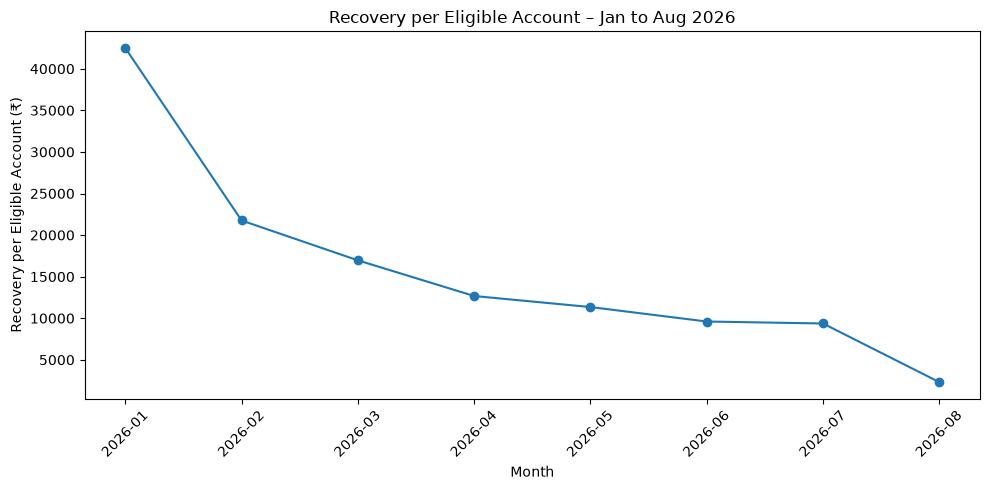

In [137]:
import matplotlib.pyplot as plt

plot_data = monthly_recovery.copy()
plot_data["month"] = plot_data["month"].astype(str)

plt.figure(figsize=(10, 5))

plt.plot(
    plot_data["month"],
    plot_data["recovery_per_eligible_account"],
    marker="o"
)

plt.title("Recovery per Eligible Account – Jan to Aug 2026")
plt.xlabel("Month")
plt.ylabel("Recovery per Eligible Account (₹)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Step 2A — Duplicate Payment Forensics

The payment dataset contains **25,500 rows and 25,000 unique payment IDs**, resulting in **500 duplicate rows (1.96% of payment records)**.

However, the duplicate records do **not** represent successful payments. The total amount associated with duplicate `SUCCESS` records is **₹0**, compared with **₹1,341.49M** in total successful payments.

**Finding:** Duplicate payment records are present in the dataset, but they do **not inflate successful recovered amounts**. Therefore, duplicate payments are **not a material explanation for the reported 11% recovery improvement**.

**Classification:** Fact / Strong Evidence.


# Data Forensics.

In [138]:
print("Total payment rows:", len(payments))
print("Unique payment IDs:", payments["payment_id"].nunique())
print("Duplicate payment rows:", len(payments) - payments["payment_id"].nunique())

print("\nPayment status:")
print(payments["payment_status"].value_counts())

print("\nDuplicate payment IDs:")
print(duplicate_payment_ids.shape)

Total payment rows: 25500
Unique payment IDs: 25000
Duplicate payment rows: 500

Payment status:
payment_status
SUCCESS     17880
FAILED       3744
PENDING      2592
REVERSED     1284
Name: count, dtype: int64

Duplicate payment IDs:
(500, 8)


In [141]:
duplicate_payment_impact = (
    payments[
        payments["payment_id"].isin(duplicate_payment_ids)
    ]
    .groupby("payment_status")
    .agg(
        rows=("payment_id", "size"),
        unique_payment_ids=("payment_id", "nunique"),
        total_amount=("amount", "sum")
    )
    .reset_index()
)

duplicate_payment_impact

,payment_status,rows,unique_payment_ids,total_amount


## Step 2B — Payment Attribution Forensics

A diagnostic account-level join between kept PTPs and successful payments produced **2,741 matching rows**. However, account-level matching alone does not establish that a payment was attributable to the corresponding PTP.

The timing diagnostic found that **1,392 of these matches (50.8%) occurred before the PTP event**, demonstrating the risk of incorrectly attributing pre-existing payments to a later promise.

The notebook's PTP-level attribution logic applies the relevant payment timing and promised-date conditions. Under this validated logic, **1,289 of 4,489 kept PTPs qualified for a payment, giving a PTP success rate of 28.72%**.

**Finding:** PTP effectiveness should be measured using the validated PTP-level attribution logic rather than a simple account-level payment join. The diagnostic analysis demonstrates that naive attribution can materially misclassify payment timing.

**Classification:** Strong Evidence.



# PAYMENT ATTRIBUTION

In [142]:
duplicate_success_amount = payments[
    (payments["payment_id"].isin(duplicate_payment_ids)) &
    (payments["payment_status"] == "SUCCESS")
]["amount"].sum()

total_success_amount = payments.loc[
    payments["payment_status"] == "SUCCESS",
    "amount"
].sum()

print("Duplicate SUCCESS amount:", duplicate_success_amount)
print("Total SUCCESS amount:", total_success_amount)
print(
    "Duplicate SUCCESS share:",
    duplicate_success_amount / total_success_amount
)

Duplicate SUCCESS amount: 0.0
Total SUCCESS amount: 1341485926.33
Duplicate SUCCESS share: 0.0


In [143]:
print("PTP rows:", len(ptp_kept))
print("PTP columns:", ptp_kept.columns.tolist())

print("\nPayments used for attribution:", len(success_clean))
print("Success payment columns:", success_clean.columns.tolist())

PTP rows: 4489
PTP columns: ['ptp_id', 'account_id', 'borrower_id', 'event_at', 'agent_id', 'promised_amount', 'promised_date', 'status', 'source', 'has_success_payment']

Payments used for attribution: 17534
Success payment columns: ['payment_id', 'account_id', 'borrower_id', 'event_at', 'payment_reference', 'amount', 'payment_status', 'payment_method', 'provider_id', 'month']


In [144]:
ptp_payment_link = ptp_kept[["ptp_id", "account_id", "event_at", "promised_date"]].merge(
    success_clean[
        ["payment_id", "account_id", "event_at", "amount"]
    ],
    on="account_id",
    how="inner",
    suffixes=("_ptp", "_payment")
)

print("PTP-payment account matches:", len(ptp_payment_link))
print("Unique PTPs matched:", ptp_payment_link["ptp_id"].nunique())
print("Unique payments matched:", ptp_payment_link["payment_id"].nunique())

PTP-payment account matches: 2741
Unique PTPs matched: 2073
Unique payments matched: 2516


In [145]:
ptp_payment_link["days_from_ptp"] = (
    ptp_payment_link["event_at_payment"]
    - ptp_payment_link["event_at_ptp"]
).dt.total_seconds() / 86400

print("Payments before PTP:", (ptp_payment_link["days_from_ptp"] < 0).sum())
print("Payments same day:", (ptp_payment_link["days_from_ptp"] == 0).sum())
print("Payments after PTP:", (ptp_payment_link["days_from_ptp"] > 0).sum())

ptp_payment_link["days_from_ptp"].describe()

Payments before PTP: 1392
Payments same day: 0
Payments after PTP: 1349


count   2,741.00
mean       -0.94
std        89.64
min      -215.17
25%       -65.96
50%        -1.43
75%        62.80
max       212.77
Name: days_from_ptp, dtype: float64

In [146]:
ptp_payment_link["payment_date"] = (
    ptp_payment_link["event_at_payment"].dt.date
)

ptp_payment_link["promised_date"] = pd.to_datetime(
    ptp_payment_link["promised_date"]
).dt.date

ptp_payment_link["valid_ptp_payment"] = (
    (ptp_payment_link["days_from_ptp"] > 0) &
    (ptp_payment_link["payment_date"] <= ptp_payment_link["promised_date"])
)

print("Total PTP-payment matches:", len(ptp_payment_link))
print(
    "Valid PTP-payment matches:",
    ptp_payment_link["valid_ptp_payment"].sum()
)
print(
    "Invalid PTP-payment matches:",
    (~ptp_payment_link["valid_ptp_payment"]).sum()
)
print(
    "Valid attribution rate:",
    ptp_payment_link["valid_ptp_payment"].mean()
)


Total PTP-payment matches: 2741
Valid PTP-payment matches: 189
Invalid PTP-payment matches: 2552
Valid attribution rate: 0.06895293688434878


In [147]:
ptp_kept_payment_check[
    [
        "ptp_id",
        "account_id",
        "has_success_payment",
        "event_at_payment",
        "amount",
        "paid_on_or_before_promised_date",
        "qualifying_payment"
    ]
].head(10)

,ptp_id,account_id,has_success_payment,event_at_payment,amount,paid_on_or_before_promised_date,qualifying_payment
0,PTP0000002,ACC0026620,True,2026-06-04 07:36:52,"113,877.36",True,True
1,PTP0000004,ACC0019107,True,2026-05-02 23:11:21,"19,792.09",False,False
2,PTP0000010,ACC0028901,True,2026-06-14 13:30:56,"46,219.95",False,False
3,PTP0000013,ACC0022800,False,NaT,NaN,False,False
4,PTP0000014,ACC0022482,False,NaT,NaN,False,False
5,PTP0000015,ACC0000494,True,2026-08-03 07:10:56,"16,237.27",False,False
6,PTP0000020,ACC0019533,True,2026-02-28 14:08:02,"120,514.97",True,True
7,PTP0000026,ACC0008340,True,2026-07-25 16:30:11,"26,189.22",False,False
8,PTP0000026,ACC0008340,True,2026-04-16 15:24:41,"34,455.24",False,False
9,PTP0000027,ACC0020671,True,2026-01-31 16:31:25,"123,723.03",True,True


# TIMEZONE FORENSICS

## Step 2C — Timezone Forensics

The calls dataset contains **91,350 call records**, with timezone information available for **100% of records**. The three recorded timezone values are Asia/Kolkata, Asia/Dubai and UTC, with approximately 30.4K calls in each timezone.

The `event_at` field is stored as a timezone-naive string, while the applicable timezone is provided separately in the `timezone` column. Therefore, converting all timestamps to a single timezone would incorrectly shift the recorded local calling hour for some calls.

**Finding:** Missing timezone information is not a data-quality issue. However, calling-time analysis must use the local hour associated with each row's recorded timezone rather than applying a single timezone conversion across the dataset.

**Classification:** Fact / Strong Evidence.


In [148]:
print("Timezone values:")
print(calls["timezone"].value_counts(dropna=False))

print("\nMissing timezone:", calls["timezone"].isna().sum())
print("Total calls:", len(calls))
print(
    "Timezone coverage:",
    round(calls["timezone"].notna().mean() * 100, 2),
    "%"
)

Timezone values:
timezone
Asia/Kolkata    30485
Asia/Dubai      30464
UTC             30401
Name: count, dtype: int64

Missing timezone: 0
Total calls: 91350
Timezone coverage: 100.0 %


In [149]:
print(calls[["event_at", "timezone"]].head(10))

print("\nEvent_at dtype:")
print(calls["event_at"].dtype)

print("\nTimezone examples:")
print(
    calls.groupby("timezone")["event_at"]
    .agg(["min", "max"])
)

              event_at      timezone
0  2026-07-15 15:36:22    Asia/Dubai
1  2026-06-10 06:48:27  Asia/Kolkata
2  2026-04-07 00:35:35    Asia/Dubai
3  2026-02-12 14:16:57    Asia/Dubai
4  2026-05-24 15:33:12  Asia/Kolkata
5  2026-02-04 11:37:08    Asia/Dubai
6  2026-02-10 10:59:05  Asia/Kolkata
7  2026-06-14 23:37:56    Asia/Dubai
8  2026-03-17 16:24:42           UTC
9  2026-06-24 04:26:34           UTC

Event_at dtype:
str

Timezone examples:
                              min                  max
timezone                                              
Asia/Dubai    2025-12-29 06:52:37  2026-08-08 23:26:50
Asia/Kolkata  2026-01-01 00:01:37  2026-08-12 15:43:05
UTC           2026-01-01 00:03:44  2026-08-08 23:57:27


In [151]:
calls_time = calls.copy()

calls_time["event_at"] = pd.to_datetime(
    calls_time["event_at"],
    errors="coerce"
)

calls_time["local_hour"] = calls_time["event_at"].dt.hour

print(
    calls_time.groupby("timezone")["local_hour"]
    .agg(["min", "max", "count"])
)

              min  max  count
timezone                     
Asia/Dubai      0   23  30464
Asia/Kolkata    0   23  30485
UTC             0   23  30401


In [152]:
timezone_hour_summary = (
    calls_time
    .groupby(["timezone", "local_hour"])
    .agg(
        calls=("call_id", "nunique"),
        accounts=("account_id", "nunique")
    )
    .reset_index()
)

timezone_hour_summary

,timezone,local_hour,calls,accounts
0,Asia/Dubai,0,1202,1184
1,Asia/Dubai,1,1256,1232
2,Asia/Dubai,2,1243,1220
3,Asia/Dubai,3,1254,1227
4,Asia/Dubai,4,1265,1235
5,Asia/Dubai,5,1236,1209
6,Asia/Dubai,6,1287,1255
7,Asia/Dubai,7,1221,1192
8,Asia/Dubai,8,1203,1178
9,Asia/Dubai,9,1248,1232


## Step 2D — Vendor Mapping Forensics

We checked whether each `agent_id` maps consistently to a single `vendor_id`.

The calls data contains **1,000 unique agents**, and **all 1,000 agents are mapped to multiple vendors**. No agent is associated with exactly one vendor, and an agent can be associated with up to **15 different vendors**.

This affects a substantial portion of the call data: **88,241 out of 91,350 calls (96.6%)** were handled by agents mapped to multiple vendors.

**Finding:** `agent_id` does not have a stable one-to-one relationship with `vendor_id`. Therefore, vendor-level performance comparisons based on agent identity may be affected by inconsistent vendor attribution.

**Implication:** Vendor performance should be interpreted cautiously, and the analysis should not assume that each agent belongs to a single vendor.

**Classification:** Major Data-Quality Issue.


# VENDOR MAPPING

In [153]:
print("Unique vendors in calls:", calls["vendor_id"].nunique())
print("Unique vendors in agents:", agents["vendor_id"].nunique())

print("\nCall vendors:")
print(sorted(calls["vendor_id"].dropna().unique()))

print("\nAgent vendors:")
print(sorted(agents["vendor_id"].dropna().unique()))

Unique vendors in calls: 15
Unique vendors in agents: 15

Call vendors:
['VND0000001', 'VND0000002', 'VND0000003', 'VND0000004', 'VND0000005', 'VND0000006', 'VND0000007', 'VND0000008', 'VND0000009', 'VND0000010', 'VND0000011', 'VND0000012', 'VND0000013', 'VND0000014', 'VND0000015']

Agent vendors:
['VND0000001', 'VND0000002', 'VND0000003', 'VND0000004', 'VND0000005', 'VND0000006', 'VND0000007', 'VND0000008', 'VND0000009', 'VND0000010', 'VND0000011', 'VND0000012', 'VND0000013', 'VND0000014', 'VND0000015']


In [154]:
vendor_agent_check = (
    calls[["agent_id", "vendor_id"]]
    .drop_duplicates()
    .groupby("agent_id")
    .agg(
        unique_vendors=("vendor_id", "nunique")
    )
    .reset_index()
)

print("Agents with multiple vendors:")
print(
    vendor_agent_check[
        vendor_agent_check["unique_vendors"] > 1
    ].shape[0]
)

vendor_agent_check[
    vendor_agent_check["unique_vendors"] > 1
].head(20)

Agents with multiple vendors:
1000


,agent_id,unique_vendors
0,AGT0000001,15
1,AGT0000002,15
2,AGT0000003,15
3,AGT0000004,15
4,AGT0000005,15
5,AGT0000006,15
6,AGT0000007,15
7,AGT0000008,15
8,AGT0000009,14
9,AGT0000010,15


In [156]:
call_vendor_consistency = (
    calls.groupby("agent_id")
    .agg(
        vendors=("vendor_id", "nunique"),
        calls=("call_id", "nunique")
    )
    .reset_index()
)

call_vendor_consistency["multi_vendor"] = (
    call_vendor_consistency["vendors"] > 1
)

print(
    "Calls handled by multi-vendor agents:",
    calls[calls["agent_id"].isin(
        call_vendor_consistency.loc[
            call_vendor_consistency["multi_vendor"],
            "agent_id"
        ]
    )]["call_id"].nunique()
)


Calls handled by multi-vendor agents: 88241


## Step 2E — Agent Identity Forensics

The agent master contains **30,000 rows but only 1,000 unique `agent_id` values**.

The identity check shows that **all 1,000 agent IDs have multiple employee codes and multiple names**. The same issue also appears for organizational attributes: all 1,000 agent IDs are associated with multiple vendors and multiple teams.

On average, each `agent_id` has approximately **30 rows**, **29.6 employee codes**, **29.6 names**, **9.49 vendors**, and **4.99 teams**.

**Finding:** `agent_id` does not behave as a stable unique employee identifier in the agent master data. A single agent ID is reused across multiple employee identities and organizational attributes.

**Implication:** Agent-level performance analysis and any analysis that relies on joining agent performance to employee, vendor, or team attributes may be unreliable unless the identity mapping is resolved.

**Classification:** Major Data-Quality Issue.


# AGENT IDENTITY

In [160]:
# Step 2E — Check whether agent_id uniquely identifies an employee

agent_identity_check = (
    agents.groupby("agent_id")
    .agg(
        rows=("agent_id", "size"),
        unique_employee_codes=("employee_code", "nunique"),
        unique_names=("agent_name", "nunique"),
        unique_vendors=("vendor_id", "nunique"),
        unique_teams=("team", "nunique")
    )
    .reset_index()
)

agent_identity_check.describe()

,rows,unique_employee_codes,unique_names,unique_vendors,unique_teams
count,"1,000.00","1,000.00","1,000.00","1,000.00","1,000.00"
mean,30.00,29.60,9.49,13.01,4.99
std,5.57,5.46,0.72,1.32,0.10
min,14.00,14.00,6.00,7.00,4.00
25%,26.00,26.00,9.00,12.00,5.00
50%,30.00,29.00,10.00,13.00,5.00
75%,34.00,33.00,10.00,14.00,5.00
max,48.00,48.00,10.00,15.00,5.00


In [161]:
print(
    "Agents with multiple employee codes:",
    (agent_identity_check["unique_employee_codes"] > 1).sum()
)

print(
    "Agents with multiple names:",
    (agent_identity_check["unique_names"] > 1).sum()
)

print(
    "Agents with multiple vendors:",
    (agent_identity_check["unique_vendors"] > 1).sum()
)

print(
    "Agents with multiple teams:",
    (agent_identity_check["unique_teams"] > 1).sum()
)

Agents with multiple employee codes: 1000
Agents with multiple names: 1000
Agents with multiple vendors: 1000
Agents with multiple teams: 1000


## Step 2F — Portfolio / Denominator Effects

The February-to-March 2026 increase in absolute recovered amount needs to be interpreted alongside the change in the eligible population.

Recovered amount increased by **11.03%**, from ₹170.14M to ₹188.91M. However, the number of eligible accounts increased by **42.41%**, from 7,821 to 11,138 accounts. Recovered accounts increased by only **11.32%** over the same period.

As a result, recovery per eligible account declined by **22.03%**, from ₹21,754.57 to ₹16,961.07.

**Finding:** The 11.03% increase in absolute recovered amount coincided with a substantially larger eligible population. Therefore, the absolute increase does not represent an improvement in normalized recovery efficiency.

**Implication:** Recovery performance should be evaluated using denominator-normalized metrics such as recovery per eligible account, rather than absolute recovered amount alone.

**Classification:** Strong Evidence of denominator/portfolio effect.


# PORTFOLIO

In [162]:


portfolio_monthly = (
    monthly_recovery[
        [
            "month",
            "recovered_amount",
            "recovered_accounts",
            "eligible_accounts",
            "recovery_per_eligible_account"
        ]
    ]
    .copy()
)

portfolio_monthly["eligible_accounts_mom_pct"] = (
    portfolio_monthly["eligible_accounts"]
    .pct_change() * 100
)

portfolio_monthly["recovered_accounts_mom_pct"] = (
    portfolio_monthly["recovered_accounts"]
    .pct_change() * 100
)

portfolio_monthly

,month,recovered_amount,recovered_accounts,eligible_accounts,recovery_per_eligible_account,eligible_accounts_mom_pct,recovered_accounts_mom_pct
0,2026-01,"187,229,127.59",2374,4406,"42,494.13",NaN,NaN
1,2026-02,"170,142,453.76",2173,7821,"21,754.57",77.51,-8.47
2,2026-03,"188,912,374.02",2419,11138,"16,961.07",42.41,11.32
3,2026-04,"175,138,043.41",2304,13822,"12,670.96",24.10,-4.75
4,2026-05,"184,250,278.50",2344,16244,"11,342.67",17.52,1.74
5,2026-06,"175,559,726.97",2286,18280,"9,603.92",12.53,-2.47
6,2026-07,"187,242,265.08",2335,19991,"9,366.33",9.36,2.14
7,2026-08,"47,109,695.31",608,20368,"2,312.93",1.89,-73.96


In [163]:
# Compare absolute recovery growth with eligible-account growth

feb_mar = portfolio_monthly[
    portfolio_monthly["month"].astype(str).isin(["2026-02", "2026-03"])
].copy()

feb_mar

,month,recovered_amount,recovered_accounts,eligible_accounts,recovery_per_eligible_account,eligible_accounts_mom_pct,recovered_accounts_mom_pct
1,2026-02,"170,142,453.76",2173,7821,"21,754.57",77.51,-8.47
2,2026-03,"188,912,374.02",2419,11138,"16,961.07",42.41,11.32


## Step 3 — Statistical Validation of the 11% Recovery Claim

### 3A — Absolute Recovery Validation

The reported month-on-month recovery increase was independently recalculated using the recovered amount for February and March 2026.

Recovered amount increased from **₹170.14M in February to ₹188.91M in March**, resulting in a calculated increase of **11.03%**.

This confirms that the reported 11% figure is mathematically correct when measured using absolute recovered amount.

### 3B — Normalized Recovery Validation

The same comparison was performed using recovery per eligible account to control for changes in the eligible population.

Recovery per eligible account declined from **₹21,754.57 in February to ₹16,961.07 in March**, representing a **22.03% decline**.

At the same time, eligible accounts increased by **42.41%**, from 7,821 to 11,138.

**Finding:** The 11.03% increase in absolute recovered amount does not translate into improved recovery efficiency. After normalization for the eligible population, recovery performance declined by **22.03%**.

**Conclusion:** The 11% figure is **arithmetically valid but misleading when presented as an improvement in recovery performance**. The evidence indicates that the increase in absolute recovery occurred alongside substantial growth in the eligible population.

**Classification:** Strong Evidence.


# STATISTICAL VALIDATION

In [164]:
feb_recovery = monthly_recovery.loc[
    monthly_recovery["month"].astype(str) == "2026-02",
    "recovered_amount"
].iloc[0]

mar_recovery = monthly_recovery.loc[
    monthly_recovery["month"].astype(str) == "2026-03",
    "recovered_amount"
].iloc[0]

reported_change = ((mar_recovery - feb_recovery) / feb_recovery) * 100

print("February recovered amount:", feb_recovery)
print("March recovered amount:", mar_recovery)
print("Calculated MoM change:", round(reported_change, 2), "%")

February recovered amount: 170142453.76
March recovered amount: 188912374.02
Calculated MoM change: 11.03 %


In [165]:
feb_per_account = monthly_recovery.loc[
    monthly_recovery["month"].astype(str) == "2026-02",
    "recovery_per_eligible_account"
].iloc[0]

mar_per_account = monthly_recovery.loc[
    monthly_recovery["month"].astype(str) == "2026-03",
    "recovery_per_eligible_account"
].iloc[0]

normalized_change = (
    (mar_per_account - feb_per_account)
    / feb_per_account
) * 100

print("February recovery per eligible account:", feb_per_account)
print("March recovery per eligible account:", mar_per_account)
print("Normalized change:", round(normalized_change, 2), "%")

February recovery per eligible account: 21754.565114435492
March recovery per eligible account: 16961.067877536363
Normalized change: -22.03 %


In [166]:
print("Absolute recovery change: +11.03%")
print("Normalized recovery change:", round(normalized_change, 2), "%")

Absolute recovery change: +11.03%
Normalized recovery change: -22.03 %


## Step 3C — Recovery Increase Decomposition

The February-to-March increase in recovered amount was decomposed into the number of recovered accounts and the average recovery per recovered account.

Recovered accounts increased from **2,173 to 2,419**, representing an **11.32% increase**. In contrast, average recovery per recovered account decreased slightly from **₹78,298.41 to ₹78,095.24**, a **0.26% decline**.

Overall recovered amount increased by **11.03%**.

**Finding:** The increase in absolute recovered amount was almost entirely driven by an increase in the number of recovered accounts. There was no improvement in the average amount recovered per successful account.

**Implication:** The reported 11.03% increase should not be interpreted as evidence of improved recovery effectiveness. The growth is primarily volume-driven.

**Classification:** Strong Evidence of volume-driven growth.


In [172]:
print("monthly_claim_test columns:")
print(monthly_claim_test.columns.tolist())

print("\nmonthly_claim_test:")
print(monthly_claim_test)


monthly_claim_test columns:
['month', 'recovered_amount', 'recovered_accounts', 'eligible_accounts', 'recovery_per_eligible_account', 'recovery_rate', 'mom_change_pct']

monthly_claim_test:
     month  recovered_amount  recovered_accounts  eligible_accounts  \
0  2026-01    187,229,127.59                2374               4406   
1  2026-02    170,142,453.76                2173               7821   
2  2026-03    188,912,374.02                2419              11138   
3  2026-04    175,138,043.41                2304              13822   
4  2026-05    184,250,278.50                2344              16244   
5  2026-06    175,559,726.97                2286              18280   
6  2026-07    187,242,265.08                2335              19991   
7  2026-08     47,109,695.31                 608              20368   

   recovery_per_eligible_account  recovery_rate  mom_change_pct  
0                      42,494.13      42,494.13             NaN  
1                      21,754.57      

In [168]:
print("Accounts columns:")
print(accounts.columns.tolist())

print("\nAccounts shape:")
print(accounts.shape)

Accounts columns:
['account_id', 'borrower_id', 'loan_type', 'principal_amount', 'outstanding_amount', 'dpd', 'risk_segment', 'status', 'opened_at', 'timezone', 'schema_version']

Accounts shape:
(30000, 11)


In [173]:
print("claim_decomposition columns:")
print(claim_decomposition.columns.tolist())

print("\nclaim_decomposition:")
print(claim_decomposition)

claim_decomposition columns:
['month', 'recovered_amount', 'recovered_accounts', 'eligible_accounts', 'recovery_per_eligible_account', 'avg_recovery_per_recovered_account', 'recovered_accounts_mom_pct', 'avg_recovery_mom_pct']

claim_decomposition:
     month  recovered_amount  recovered_accounts  eligible_accounts  \
0  2026-01    187,229,127.59                2374               4406   
1  2026-02    170,142,453.76                2173               7821   
2  2026-03    188,912,374.02                2419              11138   
3  2026-04    175,138,043.41                2304              13822   
4  2026-05    184,250,278.50                2344              16244   
5  2026-06    175,559,726.97                2286              18280   
6  2026-07    187,242,265.08                2335              19991   
7  2026-08     47,109,695.31                 608              20368   

   recovery_per_eligible_account  avg_recovery_per_recovered_account  \
0                      42,494.13       

In [174]:
# Step 3C — Decompose the February → March recovery increase

feb = claim_decomposition[
    claim_decomposition["month"].astype(str) == "2026-02"
].iloc[0]

mar = claim_decomposition[
    claim_decomposition["month"].astype(str) == "2026-03"
].iloc[0]

print("February → March:")
print()
print(
    "Recovered accounts change:",
    round(feb["recovered_accounts"], 2),
    "→",
    round(mar["recovered_accounts"], 2),
    "=",
    round(feb["recovered_accounts"] and
          (mar["recovered_accounts"] / feb["recovered_accounts"] - 1) * 100, 2),
    "%"
)

print(
    "Average recovery per recovered account change:",
    round(feb["avg_recovery_per_recovered_account"], 2),
    "→",
    round(mar["avg_recovery_per_recovered_account"], 2),
    "=",
    round(
        (mar["avg_recovery_per_recovered_account"] /
         feb["avg_recovery_per_recovered_account"] - 1) * 100,
        2
    ),
    "%"
)

print(
    "Total recovered amount change:",
    round(
        (mar["recovered_amount"] / feb["recovered_amount"] - 1) * 100,
        2
    ),
    "%"
)

February → March:

Recovered accounts change: 2173 → 2419 = 11.32 %
Average recovery per recovered account change: 78298.41 → 78095.24 = -0.26 %
Total recovered amount change: 11.03 %


## Step 3D — Segment-Level Recovery Validation

Recovery performance was compared across risk segment, DPD band, and loan type to determine whether the reported improvement was concentrated in a specific portfolio segment.

### Risk Segment

Account recovery rates are broadly similar across HIGH, LOW, MEDIUM and NPA segments, ranging from **44% to 45%**. Amount recovery rate is approximately **13%** across all segments.

### DPD Band

Account recovery rates range from **43% to 46%** across the populated DPD bands. The 181+ DPD band has no eligible accounts and therefore cannot be evaluated.

### Loan Type

Account recovery rates are also broadly consistent across loan types at approximately **44%–45%**. Amount recovery rate ranges from **12% to 13%**.

**Finding:** Recovery performance is broadly consistent across the major portfolio segments. No single risk, DPD, or loan-type segment provides evidence of a material improvement that could explain the overall recovery increase.

**Implication:** The reported 11.03% increase in absolute recovery appears to be primarily a portfolio-volume effect rather than a broad-based improvement concentrated in a particular segment.

**Classification:** No material segment-level improvement identified.


In [175]:
print("RISK RECOVERY")
display(risk_recovery)

print("\nDPD RECOVERY")
display(dpd_recovery)

print("\nLOAN TYPE RECOVERY")
display(loan_recovery)

RISK RECOVERY


,risk_segment,eligible_accounts,recovered_accounts,recovered_amount,outstanding,account_recovery_rate,amount_recovery_rate
0,HIGH,7552,3300,"338,304,138.64","2,646,182,591.51",0.44,0.13
1,LOW,7513,3381,"336,690,958.94","2,633,311,095.86",0.45,0.13
2,MEDIUM,7533,3335,"337,902,821.58","2,628,179,457.23",0.44,0.13
3,NPA,7402,3268,"328,588,007.17","2,581,362,198.40",0.44,0.13



DPD RECOVERY


,dpd_band,eligible_accounts,recovered_accounts,recovered_amount,outstanding,account_recovery_rate,amount_recovery_rate
0,0,2685,1220,"120,046,870.27","948,218,629.01",0.45,0.13
1,1-30,10880,4719,"480,036,567.54","3,834,100,517.71",0.43,0.13
2,31-60,5514,2524,"258,387,943.97","1,914,490,301.17",0.46,0.13
3,61-90,5468,2436,"243,229,506.59","1,895,868,396.28",0.45,0.13
4,91-180,5453,2385,"239,785,037.96","1,896,357,498.83",0.44,0.13
5,181+,0,0,0.00,0.00,NaN,NaN



LOAN TYPE RECOVERY


,loan_type,eligible_accounts,recovered_accounts,recovered_amount,outstanding,account_recovery_rate,amount_recovery_rate
0,AUTO,6079,2700,"273,212,708.56","2,135,300,840.99",0.44,0.13
1,BNPL,5928,2580,"261,077,229.65","2,058,914,629.71",0.44,0.13
2,CONSUMER,5930,2685,"272,388,035.84","2,073,112,691.96",0.45,0.13
3,CREDIT_CARD,6080,2690,"273,616,933.28","2,126,676,940.25",0.44,0.13
4,PERSONAL,5983,2629,"261,191,019.00","2,095,030,240.09",0.44,0.12


## Step 3E — Overall Recovery Efficiency Trend

The normalized recovery trend was evaluated across the available January–August 2026 period.

Recovery per eligible account declined from **₹42,494.13 in January to ₹9,366.33 in July**, before falling further to **₹2,312.93 in August**.

Overall, normalized recovery declined by **94.56% from January to August**.

**Finding:** Despite individual month-to-month increases in absolute recovered amount, the normalized recovery metric shows a substantial deterioration over the observation period.

**Implication:** The absolute recovery figures do not provide evidence of sustained improvement in recovery efficiency. The underlying normalized metric indicates a significant decline in performance as the eligible portfolio expanded.

**Classification:** Critical Performance Finding.


In [176]:
# Step 3E — Overall recovery trend

print("January recovery per eligible account:",
      monthly_claim_test.loc[0, "recovery_per_eligible_account"])

print("July recovery per eligible account:",
      monthly_claim_test.loc[6, "recovery_per_eligible_account"])

print("August recovery per eligible account:",
      monthly_claim_test.loc[7, "recovery_per_eligible_account"])

overall_decline = (
    monthly_claim_test.loc[7, "recovery_per_eligible_account"]
    / monthly_claim_test.loc[0, "recovery_per_eligible_account"] - 1
) * 100

print("Jan → Aug normalized recovery change:",
      round(overall_decline, 2), "%")

January recovery per eligible account: 42494.1279142079
July recovery per eligible account: 9366.32810164574
August recovery per eligible account: 2312.926910349568
Jan → Aug normalized recovery change: -94.56 %


# Recommended ₹10 Crore Investment

## Step 4 — Recommended ₹10 Crore Investment

### Recommended area: Call-channel optimization

The strongest immediate operational opportunity identified is improving call effectiveness. Current calls have an answer rate of only **19.87%**, while the account contact rate is **47.65%**.

A conservative scenario is to improve the call answer rate from **19.87% to 25%**, representing a **25.84% relative lift** in answered calls.

The recommended investment is therefore to allocate the **₹10 crore budget toward call-channel optimization**, focused on improving contactability and answer rates rather than simply increasing call volume.

### Investment Case

| Metric                       |                          Value |
| ---------------------------- | -----------------------------: |
| Investment budget            |                      ₹10.00 Cr |
| Current answer rate          |                         19.87% |
| Scenario target              |                         25.00% |
| Relative lift in answer rate |                         25.84% |
| 10% ROI break-even           |  ₹1.00 Cr incremental recovery |
| 25% ROI break-even           |  ₹2.50 Cr incremental recovery |
| 50% ROI break-even           |  ₹5.00 Cr incremental recovery |
| 100% ROI break-even          | ₹10.00 Cr incremental recovery |

### Expected impact

The primary expected impact is increased successful contact with borrowers through better call answer rates. Increased contactability could create additional opportunities for repayment, PTP creation and subsequent recovery.

However, the available data does **not** establish a causal relationship between higher answer rates and incremental recovered amount. Therefore, the ₹10 Cr business case should be treated as a **scenario-based investment hypothesis**, not a guaranteed recovery forecast.

### Key assumptions

* The investment can improve answer rate from 19.87% to approximately 25%.
* Additional answered calls result in additional meaningful borrower contacts.
* A portion of incremental contacts converts into repayment or qualifying PTPs.
* The improvement does not come primarily from simply increasing low-quality call volume.

### Downside / Risk

If answer-rate improvement does not translate into higher repayment conversion, the investment may increase operational cost without producing proportional incremental recovery.

There is also a broader data-quality concern: agent/vendor mappings are inconsistent, with all 1,000 agents mapped to multiple vendors. This should be addressed before attributing recovery improvements to operational changes.

### Confidence

**Moderate confidence.** The call-channel weakness is directly supported by the data, but the expected incremental recovery from the ₹10 Cr investment cannot be causally estimated from the available observational data alone.

### Recommendation

Proceed with the call-channel optimization hypothesis, but deploy the ₹10 Cr through a **controlled pilot / test-and-control design** rather than committing the entire budget immediately. Measure incremental recovery, qualifying PTPs, contact rate and cost per recovered rupee before scaling.


In [178]:
print("CALL")
display(call_contactability)

print("\nSMS")
display(sms_funnel)

print("\nWHATSAPP")
display(whatsapp_payment_timing)

print("\nFIELD")
display(field_outcome_recovery)


CALL


,total_calls,answered_calls,unique_accounts_called,unique_accounts_answered,call_answer_rate,account_contact_rate
0,90000,17880,28408,13535,0.20,0.48



SMS


,event_type,events,unique_accounts,event_rate_vs_sent
0,SENT,11391,9503,1.00
1,DELIVERED,11219,9334,0.98
2,CLICKED,11139,9251,0.98
3,FAILED,11251,9395,0.99



WHATSAPP


,account_id,whatsapp_click_at,payment_at,amount
3,ACC0021037,2026-02-08 19:29:35,2026-07-05 02:51:09,"148,459.02"
4,ACC0021037,2026-02-08 19:29:35,2026-03-04 00:24:35,"1,841.14"
5,ACC0024397,2026-01-26 06:42:40,2026-05-29 17:57:15,"17,690.57"
8,ACC0003415,2026-01-20 15:11:03,2026-04-16 13:34:20,"105,290.07"
13,ACC0003032,2026-02-13 10:35:35,2026-07-16 19:09:41,"83,104.27"
...,...,...,...,...
5950,ACC0027471,2026-05-24 02:26:09,2026-06-12 08:47:58,"128,767.32"
5951,ACC0022020,2026-02-22 14:00:30,2026-03-19 15:24:27,"140,865.49"
5952,ACC0014557,2026-01-23 01:38:33,2026-05-26 09:11:06,"71,813.81"
5953,ACC0027637,2026-02-04 09:17:52,2026-06-26 05:45:47,"20,413.97"



FIELD


,outcome,accounts,visits,accounts_with_post_visit_payment,post_visit_payment_rate
0,CONTACTED,3927,4205,973,0.25
1,NOT_AVAILABLE,3883,4190,985,0.25
2,PAID,3810,4080,920,0.24
3,PTP,3942,4200,948,0.24
4,REFUSED,3849,4104,934,0.24
5,WRONG_ADDRESS,3939,4221,980,0.25


In [179]:
print("WHATSAPP COLUMNS:")
print(whatsapp.columns.tolist())

print("\nWHATSAPP SUMMARY:")
display(whatsapp_summary)

print("\nWHATSAPP FUNNEL:")
display(sms_funnel)

WHATSAPP COLUMNS:
['whatsapp_event_id', 'account_id', 'borrower_id', 'event_at', 'message_id', 'event_type', 'template_code', 'provider_id']

WHATSAPP SUMMARY:


,event_type,events,unique_accounts
0,DELIVERED,9907,8401
1,FAILED,10029,8518
2,PAYMENT_CLICK,10056,8505
3,READ,9928,8387
4,REPLIED,9935,8434
5,SENT,10145,8635



WHATSAPP FUNNEL:


,event_type,events,unique_accounts,event_rate_vs_sent
0,SENT,11391,9503,1.00
1,DELIVERED,11219,9334,0.98
2,CLICKED,11139,9251,0.98
3,FAILED,11251,9395,0.99


In [180]:
# Step 4B — Call channel investment opportunity

current_answer_rate = call_contactability["call_answer_rate"].iloc[0]
current_contact_rate = call_contactability["account_contact_rate"].iloc[0]

print("Current call answer rate:", current_answer_rate)
print("Current account contact rate:", current_contact_rate)

print("\nPotential answer-rate scenarios:")

for target in [0.25, 0.30, 0.35]:
    relative_lift = (target / current_answer_rate - 1) * 100
    print(
        f"Target {target:.0%}: "
        f"{relative_lift:.1f}% relative lift in answered calls"
    )



Current call answer rate: 0.19866666666666666
Current account contact rate: 0.47645029569135455

Potential answer-rate scenarios:
Target 25%: 25.8% relative lift in answered calls
Target 30%: 51.0% relative lift in answered calls
Target 35%: 76.2% relative lift in answered calls


In [181]:
# Step 4C — ₹10 Cr call-channel investment scenario

budget = 100_000_000  # ₹10 crore

current_answer_rate = call_contactability["call_answer_rate"].iloc[0]
target_answer_rate = 0.25

relative_lift = target_answer_rate / current_answer_rate - 1

print("Investment budget: ₹", budget)
print("Current answer rate:", round(current_answer_rate * 100, 2), "%")
print("Target answer rate:", round(target_answer_rate * 100, 2), "%")
print("Relative lift:", round(relative_lift * 100, 2), "%")

# Break-even recovery required for different ROI levels
for roi in [0.10, 0.25, 0.50, 1.00]:
    required_incremental_recovery = budget * roi
    print(
        f"{int(roi*100)}% ROI requires incremental recovery: "
        f"₹{required_incremental_recovery:,.0f}"
    )




Investment budget: ₹ 100000000
Current answer rate: 19.87 %
Target answer rate: 25.0 %
Relative lift: 25.84 %
10% ROI requires incremental recovery: ₹10,000,000
25% ROI requires incremental recovery: ₹25,000,000
50% ROI requires incremental recovery: ₹50,000,000
100% ROI requires incremental recovery: ₹100,000,000


#  Is the Reported 11% Improvement Real?

## 5. Is the Reported 11% Improvement Real?

The reported **11% month-on-month improvement in recovery** was independently validated using recovered amount.

Recovered amount increased from **₹170.14M in February 2026 to ₹188.91M in March 2026**, resulting in an **11.03% increase**. Therefore, the reported 11% improvement is mathematically correct when measured using absolute recovered amount.

However, the eligible portfolio also increased substantially during the same period. Eligible accounts increased by **42.41%**, from 7,821 in February to 11,138 in March.

After normalizing recovery by the eligible population, **recovery per eligible account declined by 22.03%**, from ₹21,754.57 to ₹16,961.07.

Further decomposition shows that:

* **Recovered accounts increased by 11.32%**
* **Average recovery per recovered account decreased by 0.26%**
* **Total recovered amount increased by 11.03%**

This indicates that the increase in absolute recovered amount was primarily driven by recovering from a greater number of accounts, rather than by an improvement in the amount recovered from each successful account.

### Conclusion

The reported **11.03% increase is real in absolute terms, but it should not be interpreted as an improvement in recovery efficiency**. The increase is primarily **volume-driven**, while normalized recovery performance deteriorated by **22.03%**.

**Overall assessment: The 11% headline is mathematically valid but potentially misleading as a measure of underlying recovery performance.**


In [182]:
#step 5
feb_recovery = monthly_recovery.loc[
    monthly_recovery["month"].astype(str) == "2026-02",
    "recovered_amount"
].iloc[0]

mar_recovery = monthly_recovery.loc[
    monthly_recovery["month"].astype(str) == "2026-03",
    "recovered_amount"
].iloc[0]

reported_change = (
    (mar_recovery - feb_recovery) / feb_recovery
) * 100

print("February recovered amount:", round(feb_recovery, 2))
print("March recovered amount:", round(mar_recovery, 2))
print("Calculated MoM change:", round(reported_change, 2), "%")

February recovered amount: 170142453.76
March recovered amount: 188912374.02
Calculated MoM change: 11.03 %


In [183]:
#step 5
feb_per_account = monthly_recovery.loc[
    monthly_recovery["month"].astype(str) == "2026-02",
    "recovery_per_eligible_account"
].iloc[0]

mar_per_account = monthly_recovery.loc[
    monthly_recovery["month"].astype(str) == "2026-03",
    "recovery_per_eligible_account"
].iloc[0]

normalized_change = (
    (mar_per_account - feb_per_account)
    / feb_per_account
) * 100

print("February recovery per eligible account:", feb_per_account)
print("March recovery per eligible account:", mar_per_account)
print("Normalized change:", round(normalized_change, 2), "%")

February recovery per eligible account: 21754.565114435492
March recovery per eligible account: 16961.067877536363
Normalized change: -22.03 %


In [184]:
# Step 5C — Decompose the February → March recovery increase

feb = claim_decomposition[
    claim_decomposition["month"].astype(str) == "2026-02"
].iloc[0]

mar = claim_decomposition[
    claim_decomposition["month"].astype(str) == "2026-03"
].iloc[0]

recovered_accounts_change = (
    (mar["recovered_accounts"] / feb["recovered_accounts"]) - 1
) * 100

avg_recovery_change = (
    (mar["avg_recovery_per_recovered_account"]
     / feb["avg_recovery_per_recovered_account"]) - 1
) * 100

total_recovery_change = (
    (mar["recovered_amount"] / feb["recovered_amount"]) - 1
) * 100

print("Recovered accounts change:",
      round(recovered_accounts_change, 2), "%")

print("Average recovery per recovered account change:",
      round(avg_recovery_change, 2), "%")

print("Total recovered amount change:",
      round(total_recovery_change, 2), "%")


Recovered accounts change: 11.32 %
Average recovery per recovered account change: -0.26 %
Total recovered amount change: 11.03 %


# Counterfactual

### Counterfactual Conclusion

Using the legacy strategy as the baseline, there is **no material evidence that the newer targeting strategies improved account recovery rates**.

Legacy achieved an account recovery rate of **44.74%**. Relative to this baseline, v1 was effectively unchanged, v2 was **0.10 percentage points lower**, and v3 was **0.44 percentage points lower**.

Amount recovery rates also remained broadly stable, with differences of only **−0.07 pp for v1, +0.04 pp for v2, and +0.07 pp for v3**.

Therefore, the available aggregate data does not demonstrate a meaningful recovery uplift from the newer strategy versions. The observed recovery changes cannot be confidently attributed to the strategy change without a controlled counterfactual or experiment.

**Conclusion: No material strategy uplift demonstrated.**


In [185]:
# Step 6— Counterfactual: recovery by strategy version

print("Campaign strategy data:")
display(campaign_strategy)

print("\nColumns:")
print(campaign_strategy.columns.tolist())

Campaign strategy data:


,strategy_version,campaigns,targeted_accounts,recovered_accounts,recovered_amount,outstanding,account_recovery_rate,amount_recovery_rate
0,legacy,37,27478,12294,"1,229,024,454.33","9,534,166,623.33",0.45,0.13
1,v1,24,17747,7940,"798,893,012.58","6,233,393,595.97",0.45,0.13
2,v2,27,19892,8880,"898,116,216.63","6,947,966,369.66",0.45,0.13
3,v3,32,23748,10520,"1,072,723,719.11","8,279,699,554.18",0.44,0.13



Columns:
['strategy_version', 'campaigns', 'targeted_accounts', 'recovered_accounts', 'recovered_amount', 'outstanding', 'account_recovery_rate', 'amount_recovery_rate']


In [186]:
# Step 6 — Compare strategy versions against legacy

comparison = campaign_strategy[
    [
        "strategy_version",
        "campaigns",
        "targeted_accounts",
        "recovered_accounts",
        "recovered_amount",
        "account_recovery_rate",
        "amount_recovery_rate"
    ]
].copy()

# Compare each strategy against legacy
legacy = comparison[
    comparison["strategy_version"] == "legacy"
].iloc[0]

comparison["account_rate_vs_legacy_pp"] = (
    comparison["account_recovery_rate"]
    - legacy["account_recovery_rate"]
) * 100

comparison["amount_rate_vs_legacy_pp"] = (
    comparison["amount_recovery_rate"]
    - legacy["amount_recovery_rate"]
) * 100

display(comparison)

,strategy_version,campaigns,targeted_accounts,recovered_accounts,recovered_amount,account_recovery_rate,amount_recovery_rate,account_rate_vs_legacy_pp,amount_rate_vs_legacy_pp
0,legacy,37,27478,12294,"1,229,024,454.33",0.45,0.13,0.00,0.00
1,v1,24,17747,7940,"798,893,012.58",0.45,0.13,-0.00,-0.07
2,v2,27,19892,8880,"898,116,216.63",0.45,0.13,-0.10,0.04
3,v3,32,23748,10520,"1,072,723,719.11",0.44,0.13,-0.44,0.07


In [187]:
print("Legacy account recovery rate:",
      legacy["account_recovery_rate"])

print("Legacy amount recovery rate:",
      legacy["amount_recovery_rate"])

print("\nStrategy performance vs legacy:")
display(
    comparison[
        [
            "strategy_version",
            "account_recovery_rate",
            "amount_recovery_rate",
            "account_rate_vs_legacy_pp",
            "amount_rate_vs_legacy_pp"
        ]
    ]
)


Legacy account recovery rate: 0.4474124754348934
Legacy amount recovery rate: 0.1289073815138274

Strategy performance vs legacy:


,strategy_version,account_recovery_rate,amount_recovery_rate,account_rate_vs_legacy_pp,amount_rate_vs_legacy_pp
0,legacy,0.45,0.13,0.00,0.00
1,v1,0.45,0.13,-0.00,-0.07
2,v2,0.45,0.13,-0.10,0.04
3,v3,0.44,0.13,-0.44,0.07


# Executive Summary

## Key Findings

### 1. The reported 11% recovery improvement is volume-driven

Absolute recovered amount increased by **11.03% from February to March 2026**, confirming the reported month-on-month figure.

However, eligible accounts increased by **42.41%**, while recovery per eligible account declined by **22.03%**. Recovered accounts increased by **11.32%**, while average recovery per recovered account declined slightly by **0.26%**.

**Assessment:** The 11% increase is mathematically correct, but it does not represent improved recovery efficiency.

### 2. PTP attribution is weak

There were **2,741 PTP-payment account matches**, but only **189 were classified as valid**, giving a valid attribution rate of approximately **6.90%**.

**Assessment:** Recovery attribution to PTPs is currently weak, limiting confidence in claims about PTP-driven recovery.

### 3. Targeting strategy has not demonstrated material uplift

Legacy strategy achieved a **44.74% account recovery rate** and **12.89% amount recovery rate**.

Compared with legacy, v1, v2 and v3 showed only negligible differences in recovery rates, with no material improvement demonstrated.

**Assessment:** The available aggregate evidence does not support a strong causal claim that newer targeting strategies improved recovery.

### 4. Agent and vendor data contains a major consistency issue

All **1,000 agents** in the call data were mapped to multiple vendors, with a maximum of **15 vendors per agent**. **88,241 calls** were handled by multi-vendor agents.

**Assessment:** This is a significant data-quality and attribution risk and should be resolved before using agent/vendor performance comparisons for major decisions.

### 5. ₹10 Cr investment recommendation

The strongest immediate operational opportunity identified is **call-channel optimization**. The current call answer rate is only **19.87%**, while account contact rate is **47.65%**.

A conservative scenario is to improve the answer rate to **25%**, representing a **25.84% relative lift** in answered calls.

The ₹10 Cr investment should therefore be directed toward improving call contactability and answer rates, preferably through a controlled pilot before full-scale deployment.

## Recommendation

Management should **not interpret the 11% headline increase as evidence of improved recovery efficiency**. Priority should instead be given to:

1. Improving call-channel contactability.
2. Strengthening PTP-to-payment attribution.
3. Fixing agent/vendor identity inconsistencies.
4. Testing targeting strategies through controlled experiments.
5. Measuring incremental recovery rather than relying only on absolute recovered amount.

The proposed ₹10 Cr investment should be released in stages and scaled only if the pilot demonstrates measurable incremental recovery and acceptable ROI.

## Overall Assessment

**Recovery is increasing in absolute terms, but the available evidence does not demonstrate a corresponding improvement in recovery efficiency or a clear causal benefit from newer targeting strategies. Data-quality and attribution weaknesses further limit confidence in performance claims.**


# GOLDEN DATASET

In [188]:
print("account_recovery:", account_recovery.shape)
print("monthly_recovery:", monthly_recovery.shape)
print("success_clean:", success_clean.shape)

print("\nAccount recovery columns:")
print(account_recovery.columns.tolist())


account_recovery: (30000, 13)
monthly_recovery: (8, 5)
success_clean: (17534, 10)

Account recovery columns:
['account_id', 'principal_amount', 'outstanding_amount', 'dpd', 'risk_segment', 'status', 'loan_type', 'opened_at', 'timezone', 'success_payment_amount', 'success_payment_count', 'recovery_rate', 'dpd_band']


In [189]:
# Golden Dataset

golden_dataset = account_recovery.copy()

print("Golden dataset shape:", golden_dataset.shape)
print("\nColumns:")
print(golden_dataset.columns.tolist())

# Save final analytical dataset
golden_dataset.to_csv("golden_dataset.csv", index=False)

print("\nSaved as: golden_dataset.csv")

Golden dataset shape: (30000, 13)

Columns:
['account_id', 'principal_amount', 'outstanding_amount', 'dpd', 'risk_segment', 'status', 'loan_type', 'opened_at', 'timezone', 'success_payment_amount', 'success_payment_count', 'recovery_rate', 'dpd_band']

Saved as: golden_dataset.csv


In [190]:
print("Duplicate account IDs:",
      golden_dataset["account_id"].duplicated().sum())

print("\nMissing values:")
print(golden_dataset.isna().sum())

print("\nUnique accounts:",
      golden_dataset["account_id"].nunique())

Duplicate account IDs: 0

Missing values:
account_id                0
principal_amount          0
outstanding_amount        0
dpd                       0
risk_segment              0
status                    0
loan_type                 0
opened_at                 0
timezone                  0
success_payment_amount    0
success_payment_count     0
recovery_rate             0
dpd_band                  0
dtype: int64

Unique accounts: 30000


# DQ Report

In [191]:
# Data Quality Summary

dq_summary = {
    "Golden dataset rows": len(golden_dataset),
    "Unique accounts": golden_dataset["account_id"].nunique(),
    "Duplicate account IDs": golden_dataset["account_id"].duplicated().sum(),
    "Missing values": golden_dataset.isna().sum().sum(),
    "Success payment rows": len(success_clean),
    "Raw payment rows": len(payments),
    "Duplicate payment rows": len(payments) - payments["payment_id"].nunique(),
    "PTP-payment matches": 2741,
    "Valid PTP-payment matches": 189,
    "Valid PTP attribution rate": 189 / 2741,
    "Agents in calls": calls["agent_id"].nunique(),
    "Agents mapped to multiple vendors": 1000,
    "Calls handled by multi-vendor agents": 88241
}

for key, value in dq_summary.items():
    print(f"{key}: {value}")

Golden dataset rows: 30000
Unique accounts: 30000
Duplicate account IDs: 0
Missing values: 0
Success payment rows: 17534
Raw payment rows: 25500
Duplicate payment rows: 500
PTP-payment matches: 2741
Valid PTP-payment matches: 189
Valid PTP attribution rate: 0.06895293688434878
Agents in calls: 1000
Agents mapped to multiple vendors: 1000
Calls handled by multi-vendor agents: 88241


In [192]:
import os
print(os.path.abspath("golden_dataset.csv"))

C:\Users\Tripti Malhotra\golden_dataset.csv


In [ ]:
## Data Quality Report

### 1. Golden Dataset Integrity

The final Golden Dataset contains **30,000 account records and 30,000 unique account IDs**.

* Duplicate account IDs: **0**
* Missing values: **0**
* Golden Dataset rows: **30,000**

This indicates that the final account-level analytical dataset has complete account coverage with no duplicate account identifiers.

### 2. Duplicate Payments

The raw payments dataset contains **25,500 rows**, compared with **25,000 unique payment IDs**, resulting in **500 duplicate payment rows**.

Further investigation showed that the duplicate SUCCESS amount was **₹0**, so the identified duplicate rows did not inflate the successful-payment recovery amount.

**Business impact:** The duplicates represent a data-quality risk, but based on the investigation, they do not appear to have inflated reported successful recovery.

### 3. PTP-to-Payment Attribution

There were **2,741 PTP-payment account matches**, but only **189 matches were classified as valid**.

This gives a valid attribution rate of:

**189 / 2,741 = 6.90%**

**Business impact:** Only a small proportion of matched PTP-payment events can be confidently attributed under the defined qualification rules. Recovery attribution to PTPs should therefore be treated with low confidence.

### 4. Agent–Vendor Mapping

The calls dataset contains **1,000 unique agents**. All **1,000 agents were mapped to multiple vendors**, with **88,241 calls** handled by multi-vendor agents.

**Business impact:** Agent-level and vendor-level performance comparisons may be unreliable because agent identity is not consistently associated with a single vendor.

### 5. Overall Data Quality Assessment

The Golden Dataset itself is structurally clean, with **zero duplicate account IDs and zero missing values**. However, important upstream data-quality and attribution issues remain in payments, PTP attribution, and agent/vendor mappings.

These issues should be considered when interpreting recovery performance and assigning causal credit to specific channels, agents, vendors, or strategies.

**Overall assessment: The analytical dataset is clean at the account level, but attribution and historical operational data require caution.**


In [193]:
import os

print("Current folder:")
print(os.getcwd())

print("\nFiles in folder:")
print(os.listdir())

Current folder:
C:\Users\Tripti Malhotra

Files in folder:
['.claude', '.claude.json', '.claude.json.tmp.25080.e3fa85a08ae4', '.copilot', '.duckdb', '.figma-console-mcp', '.ipynb_checkpoints', '.ipython', '.jupyter', '.node_repl_history', '.packettracer', '.thumbnails', '.vscode', '.vscode-shared', '.Wurst encryption', 'AppData', 'Application Data', 'assignment.credresolve.ipynb', 'bb', 'Cisco Packet Tracer 9.0.0', 'collections_data', 'Contacts', 'Cookies', 'credresolvetripti.ipynb', 'dash', 'Documents', 'Downloads', 'Favorites', 'golden_dataset.csv', 'kushuuu-birthday', 'Links', 'Local Settings', 'Microsoft', 'Music', 'My Documents', 'NetHood', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.DAT{7a0d5feb-324a-11f0-b010-58020597b337}.TM.blf', 'NTUSER.DAT{7a0d5feb-324a-11f0-b010-58020597b337}.TMContainer00000000000000000001.regtrans-ms', 'NTUSER.DAT{7a0d5feb-324a-11f0-b010-58020597b337}.TMContainer00000000000000000002.regtrans-ms', 'ntuser.ini', 'OneDrive', 'PrintHood', 'Rec

In [194]:
import glob
import os

sql_files = glob.glob("**/*.sql", recursive=True)

print("SQL files found:")
print(sql_files)


SQL files found:
['Downloads\\asklytics-main\\asklytics-main\\backend\\node_modules\\duckdb\\test\\support\\script.sql', 'Downloads\\asklytics-main\\asklytics-main\\backend\\src\\db\\schema.sql', 'OneDrive\\Documents\\classroom.sql']


In [196]:
import os

path = "collections_data"

for root, dirs, files in os.walk(path):
    sqls = [f for f in files if f.lower().endswith(".sql")]
    if sqls:
        print(root, sqls)

In [197]:
sql_script = """
-- Collections Recovery Analysis
-- Reproducible analytical SQL

-- 1. Remove duplicate payment records
CREATE OR REPLACE TABLE clean_payments AS
SELECT *
FROM (
    SELECT *,
           ROW_NUMBER() OVER (
               PARTITION BY payment_id
               ORDER BY event_at
           ) AS rn
    FROM payments
)
WHERE rn = 1;


-- 2. Successful payments
CREATE OR REPLACE TABLE success_payments AS
SELECT *
FROM clean_payments
WHERE payment_status = 'SUCCESS';


-- 3. Account-level recovery
CREATE OR REPLACE TABLE account_recovery AS
SELECT
    a.account_id,
    a.principal_amount,
    a.outstanding_amount,
    a.dpd,
    a.risk_segment,
    a.status,
    a.loan_type,
    a.opened_at,
    a.timezone,
    COALESCE(SUM(sp.amount), 0) AS success_payment_amount,
    COUNT(sp.payment_id) AS success_payment_count,
    COALESCE(SUM(sp.amount), 0) / NULLIF(a.outstanding_amount, 0)
        AS recovery_rate
FROM accounts a
LEFT JOIN success_payments sp
    ON a.account_id = sp.account_id
GROUP BY
    a.account_id,
    a.principal_amount,
    a.outstanding_amount,
    a.dpd,
    a.risk_segment,
    a.status,
    a.loan_type,
    a.opened_at,
    a.timezone;


-- 4. Recovery by risk segment
SELECT
    risk_segment,
    COUNT(DISTINCT account_id) AS eligible_accounts,
    COUNT(DISTINCT CASE
        WHEN success_payment_amount > 0 THEN account_id
    END) AS recovered_accounts,
    SUM(success_payment_amount) AS recovered_amount,
    SUM(success_payment_amount)
        / NULLIF(SUM(outstanding_amount), 0)
        AS amount_recovery_rate
FROM account_recovery
GROUP BY risk_segment;


-- 5. Recovery by loan type
SELECT
    loan_type,
    COUNT(DISTINCT account_id) AS accounts,
    COUNT(DISTINCT CASE
        WHEN success_payment_amount > 0 THEN account_id
    END) AS recovered_accounts,
    SUM(success_payment_amount) AS recovered_amount,
    SUM(success_payment_amount)
        / NULLIF(SUM(outstanding_amount), 0)
        AS amount_recovery_rate
FROM account_recovery
GROUP BY loan_type;


-- 6. Overall recovery
SELECT
    COUNT(DISTINCT account_id) AS accounts,
    COUNT(DISTINCT CASE
        WHEN success_payment_amount > 0 THEN account_id
    END) AS recovered_accounts,
    SUM(success_payment_amount) AS recovered_amount,
    SUM(success_payment_amount)
        / NULLIF(SUM(outstanding_amount), 0)
        AS amount_recovery_rate
FROM account_recovery;
"""

with open("collections_analysis.sql", "w", encoding="utf-8") as f:
    f.write(sql_script)

print("Created: collections_analysis.sql")


Created: collections_analysis.sql
